In [86]:
import os
import sys
# sys.path.insert(1, '')
current_directory = os.getcwd()
print("Current Working Directory:", current_directory)

import vit_3d
import climate_dataset
import vivit
data_path = '/mnt/home/hwalters/data'
import numpy as np
import matplotlib.pyplot as plt

import fiona
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import pickle
from time import time
from tqdm import tqdm
import xarray as xr
import torch
import torch.nn as nn
import matplotlib.colors as colors
from torch import optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.tree import plot_tree

seed = 1234
np.random.seed(seed)

Current Working Directory: /Users/hayleywalters/Desktop/research 2025/ML_rain_prediction


In [87]:
# import torch
# import numpy as np
# import torch.nn.functional as F
# from torch.utils.data import DataLoader, TensorDataset, RandomSampler

# # Define patch sizes for padding calculation
# IMAGE_PATCH_SIZE = (8, 8)  # Example patch size, adjust accordingly
# FRAME_PATCH_SIZE = 8

# def pad_video(video, patch_height, patch_width):
#     """Pads the video spatial dimensions to be divisible by the patch size."""
#     _, _, h, w = video.shape  # (Frames, Channels, Height, Width)
    
#     pad_h = (patch_height - h % patch_height) % patch_height
#     pad_w = (patch_width - w % patch_width) % patch_width

#     if pad_h > 0 or pad_w > 0:
#         padding = (0, pad_w, 0, pad_h)  # (Left, Right, Top, Bottom)
#         video = F.pad(video, padding, mode='constant', value=0)  # Pad with zeros

#     return video

# def download_and_prepare_dataset(data_path, image_patch_size=IMAGE_PATCH_SIZE):
#     """Loads and preprocesses the dataset, including padding."""
#     with np.load(data_path, allow_pickle=True) as data:
#         train_videos = np.nan_to_num(data["train_images"])
#         valid_videos = np.nan_to_num(data["val_images"])
#         test_videos = np.nan_to_num(data["test_images"])

#         train_labels = data["train_labels"]
#         valid_labels = data["val_labels"]
#         test_labels = data["test_labels"]

#     # Convert to PyTorch tensors
#     train_videos = torch.tensor(train_videos, dtype=torch.float32)
#     valid_videos = torch.tensor(valid_videos, dtype=torch.float32)
#     test_videos = torch.tensor(test_videos, dtype=torch.float32)

#     # Add channel dimension: (B, C, F, H, W)
#     train_videos = train_videos[:, None, :, :, :]
#     valid_videos = valid_videos[:, None, :, :, :]
#     test_videos = test_videos[:, None, :, :, :]

#     # Pad videos to make spatial dimensions divisible by patch size
#     train_videos = torch.stack([pad_video(v, *image_patch_size) for v in train_videos])
#     valid_videos = torch.stack([pad_video(v, *image_patch_size) for v in valid_videos])
#     test_videos = torch.stack([pad_video(v, *image_patch_size) for v in test_videos])

#     # Convert labels to tensors
#     train_labels = torch.tensor(train_labels, dtype=torch.long)
#     valid_labels = torch.tensor(valid_labels, dtype=torch.long)
#     test_labels = torch.tensor(test_labels, dtype=torch.long)

#     return (train_videos, train_labels), (valid_videos, valid_labels), (test_videos, test_labels)


# def prepare_dataloader(videos, labels, loader_type="train", batch_size=32):
#     """Creates a PyTorch DataLoader with preprocessed videos."""
#     dataset = TensorDataset(videos, labels)

#     if loader_type == "train":
#         sampler = RandomSampler(dataset)
#     else:
#         sampler = None

#     dataloader = DataLoader(
#         dataset,
#         batch_size=batch_size,
#         sampler=sampler,
#         shuffle=(sampler is None),
#         num_workers=0  # Adjust based on system
#     )
    
#     return dataloader


# # Load and preprocess dataset
# prepared_dataset = download_and_prepare_dataset("data/cluster_1_sst.npz")

# train_videos, train_labels = prepared_dataset[0]
# valid_videos, valid_labels = prepared_dataset[1]
# test_videos, test_labels = prepared_dataset[2]

# print(f'train_videos {train_videos.shape}, train_labels {train_labels.shape}')
# print(f'valid_videos {valid_videos.shape}, valid_labels {valid_labels.shape}')
# print(f'test_videos {test_videos.shape}, test_labels {test_labels.shape}')

# # Create DataLoaders
# trainloader = prepare_dataloader(train_videos, train_labels, "train", batch_size=32)
# validloader = prepare_dataloader(valid_videos, valid_labels, "valid", batch_size=32)
# testloader = prepare_dataloader(test_videos, test_labels, "test", batch_size=32)


In [88]:
# print(vit_3d.run_experiment)  # Check if it's referencing your function
# model, history = vit_3d.run_experiment(trainloader, testloader, validloader)

In [89]:
# import matplotlib.pyplot as plt
# epochs = range(1, len(history.training_loss) + 1)

# train_loss_norm = np.array(history.training_loss) / max(history.training_loss)
# valid_loss_norm = np.array(history.validation_loss) / max(history.validation_loss)

# plt.plot(epochs, train_loss_norm, label="Training Loss (normalized)")
# plt.plot(epochs, valid_loss_norm, label="Validation Loss (normalized)")

# plt.xlabel("Epochs")
# plt.ylabel("Normalized Loss")
# plt.title("Training vs Validation Loss For Cluster 1 (Normalized)")
# plt.legend()
# plt.grid(True)
# plt.show()

In [90]:
# import matplotlib.pyplot as plt
# epochs = range(1, len(history.training_loss) + 1)

# # train_loss_norm = np.array(history.training_loss) / max(history.training_loss)
# # valid_loss_norm = np.array(history.validation_loss) / max(history.validation_loss)

# plt.plot(epochs, history.training_loss, label="Training Loss")
# plt.plot(epochs, history.validation_loss, label="Validation Loss")

# plt.xlabel("Epochs")
# plt.ylabel("Normalized Loss")
# plt.title("Training vs Validation Loss For Cluster 1")
# plt.legend()
# plt.grid(True)
# plt.show()

In [91]:
# import matplotlib.pyplot as plt
# epochs = range(1, len(history.training_accuracy) + 1)

# train_acc = np.array(history.training_accuracy)
# valid_acc = np.array(history.validation_accuracy)

# plt.plot(epochs, train_acc, label="Training Accuracy")
# plt.plot(epochs, valid_acc, label="Validation Accuracy")

# plt.xlabel("Epochs")
# plt.ylabel("Accuracy")
# plt.title("Training vs Validation Accuracy For Cluster 1")
# plt.legend()
# plt.grid(True)
# plt.show()

In [92]:
# print(vit_3d.run_experiment)  # Check if it's referencing your function
# model, history = vit_3d.run_experiment(trainloader, testloader, validloader)

In [93]:
import torch
import numpy as np
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, RandomSampler

# Define patch sizes for padding calculation
IMAGE_PATCH_SIZE = (8, 8)  # Example patch size, adjust accordingly
FRAME_PATCH_SIZE = 8

def pad_video(video, patch_height, patch_width):
    """Pads the video spatial dimensions to be divisible by the patch size."""
    _, _, h, w = video.shape  # (Frames, Channels, Height, Width)
    
    pad_h = (patch_height - h % patch_height) % patch_height
    pad_w = (patch_width - w % patch_width) % patch_width

    if pad_h > 0 or pad_w > 0:
        padding = (0, pad_w, 0, pad_h)  # (Left, Right, Top, Bottom)
        video = F.pad(video, padding, mode='constant', value=0)  # Pad with zeros

    return video

def download_and_prepare_dataset(data_path, image_patch_size=IMAGE_PATCH_SIZE):
    """Loads and preprocesses the dataset, including padding."""
    with np.load(data_path, allow_pickle=True) as data:
        train_videos = np.nan_to_num(data["train_images"])
        # valid_videos = np.nan_to_num(data["val_images"])
        test_videos = np.nan_to_num(data["test_images"])

        train_labels = data["train_labels"]
        # valid_labels = data["val_labels"]
        test_labels = data["test_labels"]

    # Convert to PyTorch tensors
    train_videos = torch.tensor(train_videos, dtype=torch.float32)
    # valid_videos = torch.tensor(valid_videos, dtype=torch.float32)
    test_videos = torch.tensor(test_videos, dtype=torch.float32)

    # Add channel dimension: (B, C, F, H, W)
    train_videos = train_videos[:, None, :, :, :]
    # valid_videos = valid_videos[:, None, :, :, :]
    test_videos = test_videos[:, None, :, :, :]

    # Pad videos to make spatial dimensions divisible by patch size
    train_videos = torch.stack([pad_video(v, *image_patch_size) for v in train_videos])
    # valid_videos = torch.stack([pad_video(v, *image_patch_size) for v in valid_videos])
    test_videos = torch.stack([pad_video(v, *image_patch_size) for v in test_videos])

    # Convert labels to tensors
    train_labels = torch.tensor(train_labels, dtype=torch.long)
    # valid_labels = torch.tensor(valid_labels, dtype=torch.long)
    test_labels = torch.tensor(test_labels, dtype=torch.long)

    # return (train_videos, train_labels), (valid_videos, valid_labels), (test_videos, test_labels)
    return (train_videos, train_labels), (test_videos, test_labels)


def prepare_dataloader(videos, labels, loader_type="train", batch_size=32):
    """Creates a PyTorch DataLoader with preprocessed videos."""
    dataset = TensorDataset(videos, labels)

    if loader_type == "train":
        sampler = RandomSampler(dataset)
    else:
        sampler = None

    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        sampler=sampler,
        shuffle=(sampler is None),
        num_workers=0  # Adjust based on system
    )
    
    return dataloader


# Load and preprocess dataset
# All 9 cluster data without validation data
# if we want to include testing and validation data, use 'data/cluster_sst_with_val.npz' and uncomment the lines relating to validation
prepared_dataset = download_and_prepare_dataset("data/cluster_sst.npz")

train_videos, train_labels = prepared_dataset[0]
# valid_videos, valid_labels = prepared_dataset[1]
test_videos, test_labels = prepared_dataset[1]

print(f'train_videos {train_videos.shape}, train_labels {train_labels.shape}')
# print(f'valid_videos {valid_videos.shape}, valid_labels {valid_labels.shape}')
print(f'test_videos {test_videos.shape}, test_labels {test_labels.shape}')

# Create DataLoaders
trainloader = prepare_dataloader(train_videos, train_labels, "train", batch_size=32)
# validloader = prepare_dataloader(valid_videos, valid_labels, "valid", batch_size=32)
testloader = prepare_dataloader(test_videos, test_labels, "test", batch_size=32)


train_videos torch.Size([585, 1, 24, 96, 184]), train_labels torch.Size([585, 9])
test_videos torch.Size([147, 1, 24, 96, 184]), test_labels torch.Size([147, 9])


In [ ]:
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.decomposition import PCA
# from sklearn.metrics import accuracy_score, confusion_matrix
# from sklearn.model_selection import train_test_split
# import numpy as np
# import torch

# # Use these from your existing pipeline
# (train_videos, train_labels), (test_videos, test_labels) = download_and_prepare_dataset("data/cluster_sst.npz")

# # Flatten the video data into (num_samples, feature_dim)
# # Original shape: (B, C=1, F, H, W) → we drop C and flatten the rest
# def flatten_videos(videos_tensor):
#     videos_np = videos_tensor.squeeze(1).numpy()  # remove channel dim: (B, F, H, W)
#     B, F, H, W = videos_np.shape
#     return videos_np.reshape(B, F * H * W)

# X_train = flatten_videos(train_videos)
# X_test = flatten_videos(test_videos)

# # Convert labels to numpy and handle multi-output format
# y_train = train_labels.numpy()
# y_test = test_labels.numpy()

# # Optional: apply PCA to reduce dimensions
# pca_components = 50  # change based on needs
# pca = PCA(n_components=pca_components)
# X_train_pca = pca.fit_transform(X_train)
# X_test_pca = pca.transform(X_test)

# # Train a separate Random Forest for each output
# n_outputs = y_train.shape[1]
# rf_models = []
# y_preds = []

# for i in range(n_outputs):
#     # Train a model for each output
#     rf = RandomForestClassifier(max_depth=3, min_samples_leaf=100, n_estimators=200, random_state=4)
#     rf.fit(X_train_pca, y_train[:, i])
#     rf_models.append(rf)
    
#     # Make predictions
#     y_pred = rf.predict(X_test_pca)
#     y_preds.append(y_pred)

# # Stack predictions
# y_preds = np.column_stack(y_preds)

# # Calculate accuracy for each output
# accuracies = []
# for i in range(n_outputs):
#     acc = accuracy_score(y_test[:, i], y_preds[:, i])
#     accuracies.append(acc)
#     print(f"Output {i+1} Accuracy: {acc:.4f}")

# # Calculate overall accuracy (average across all outputs)
# overall_accuracy = np.mean(accuracies)
# print(f"\nOverall Random Forest Accuracy: {overall_accuracy:.4f}")


Output 1 Accuracy: 0.3333
Output 2 Accuracy: 0.2857
Output 3 Accuracy: 0.3537
Output 4 Accuracy: 0.3469
Output 5 Accuracy: 0.2993
Output 6 Accuracy: 0.3469
Output 7 Accuracy: 0.3129
Output 8 Accuracy: 0.2993
Output 9 Accuracy: 0.3061

Overall Random Forest Accuracy: 0.3205


In [104]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

import numpy as np
from sklearn.decomposition import PCA

def process_sst_tensor_data(video_tensor, pca_components, x_start, x_end, y_start, y_end):
    """
    Takes a padded PyTorch tensor of shape (samples, 1, frames, height, width)
    Slices the tensor spatially using given x/y bounds
    Flattens each sample (along time and space)
    Applies PCA and returns the reduced feature array
    """

    # video_tensor: (N_samples, 1, Frames, Height, Width)
    # Remove channel dimension -> (N, F, H, W)
    video_np = video_tensor.squeeze(1).numpy()  # (N, F, H, W)

    # Slice the spatial region
    video_np = video_np[:, :, y_start:y_end, x_start:x_end]  # (N, F, y, x)

    # Flatten (F, y, x) for each sample to a 1D array -> shape: (N, F * y * x)
    N, F, y, x = video_np.shape
    flattened = video_np.reshape(N, F * y * x)

    # Remove any columns that are all zeros (possibly due to padding)
    non_zero_cols = ~np.all(flattened == 0, axis=0)
    flattened = flattened[:, non_zero_cols]

    # Apply PCA
    pca = PCA(n_components=pca_components)
    reduced = pca.fit_transform(flattened)

    return reduced


def train_rf_per_cluster(sst_features, labels_tensor):
    """
    Train one Random Forest per cluster.
    
    Parameters:
    - sst_features: np.ndarray of shape (num_samples, num_features)
    - labels_tensor: torch.Tensor of shape (num_samples, 9)

    Returns:
    - accuracies: list of accuracy values for each cluster
    - models: list of trained RandomForestClassifier models
    """
    labels_np = labels_tensor.numpy()  # (num_samples, 9)
    n_clusters = labels_np.shape[1]

    accuracies = []
    models = []

    for i in range(n_clusters):
        y = labels_np[:, i]

        # Skip training if cluster has only one class
        if len(np.unique(y)) < 2:
            print(f"Skipping cluster {i} — only one class present.")
            accuracies.append(None)
            models.append(None)
            continue

        X_train, X_test, y_train, y_test = train_test_split(
            sst_features, y, test_size=0.25, random_state=4
        )

        rf = RandomForestClassifier(max_depth=1, min_samples_leaf=100, n_estimators=200)
        rf.fit(X_train, y_train)
        y_pred = rf.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        print(f"Accuracy for cluster {i}: {acc:.4f}")

        accuracies.append(acc)
        models.append(rf)

    return accuracies, models


TP = process_sst_tensor_data(train_videos, pca_components=2, x_start=55, x_end=144, y_start=34, y_end=56)
IO = process_sst_tensor_data(train_videos, 2, 10, 68, 34, 56)
WP = process_sst_tensor_data(train_videos, 2, 55, 85, 28, 50)
NP = process_sst_tensor_data(train_videos, 2, 59, 129, 11, 33)

sst_pca = np.hstack((IO, TP, WP, NP))  # Shape: (num_samples, total_PCA_features)
accuracies, rf_models = train_rf_per_cluster(sst_pca, train_labels)

print(f'Overall accuracy:{np.mean(accuracies)}')


Accuracy for cluster 0: 0.3878
Accuracy for cluster 1: 0.2925
Accuracy for cluster 2: 0.4286
Accuracy for cluster 3: 0.2993
Accuracy for cluster 4: 0.4218
Accuracy for cluster 5: 0.4150
Accuracy for cluster 6: 0.2925
Accuracy for cluster 7: 0.3333
Accuracy for cluster 8: 0.3878
Overall accuracy:0.3620559334845049


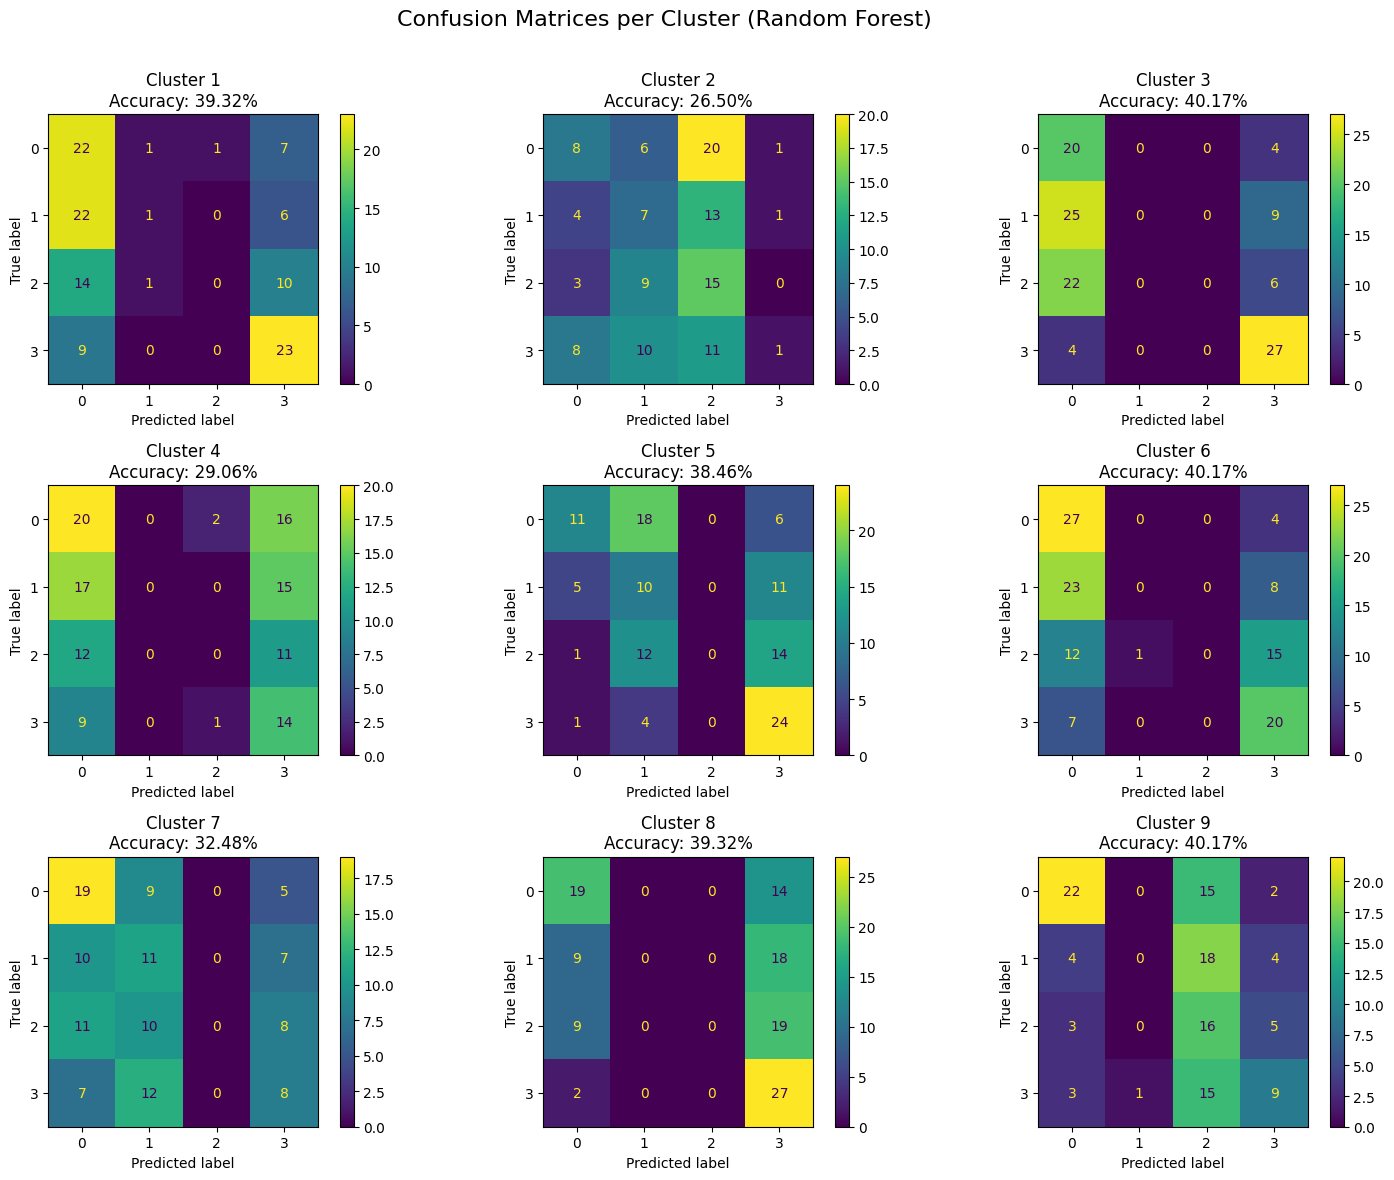

In [106]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

# Split test set from the same sst_pca features (same slice as in training loop)
_, X_test_full, _, y_test_full = train_test_split(
    sst_pca, train_labels.numpy(), test_size=0.2, random_state=4
)

n_clusters = y_test_full.shape[1]
y_preds = []

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i in range(n_clusters):
    rf = rf_models[i]

    # Skip if the model wasn’t trained (e.g., due to single class)
    if rf is None:
        print(f"Skipping confusion matrix for cluster {i} — no trained model.")
        axes[i].axis('off')
        continue

    y_test = y_test_full[:, i]
    y_pred = rf.predict(X_test_full)

    y_preds.append(y_pred)

    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=axes[i], values_format='d')
    axes[i].set_title(f"Cluster {i + 1}\nAccuracy: {acc:.2%}")

plt.suptitle("Confusion Matrices per Cluster (Random Forest)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


In [96]:
import matplotlib.pyplot as plt

def plot_feature_importances(models, region_names, pca_components_per_region):
    """
    Plot feature importances for each of the 9 cluster models.

    models: list of RandomForestClassifier
    region_names: list of region labels, e.g. ['IO', 'TP', 'WP', 'NP']
    pca_components_per_region: int (e.g. 2 if each region contributes 2 PCA features)
    """
    feature_names = []
    for region in region_names:
        for i in range(pca_components_per_region):
            feature_names.append(f'{region}_PC{i+1}')
    
    for i, model in enumerate(models):
        if model is None:
            continue
        
        importances = model.feature_importances_
        plt.figure(figsize=(8, 4))
        plt.bar(feature_names, importances)
        plt.title(f'Cluster {i} Feature Importances')
        plt.ylabel("Importance")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()


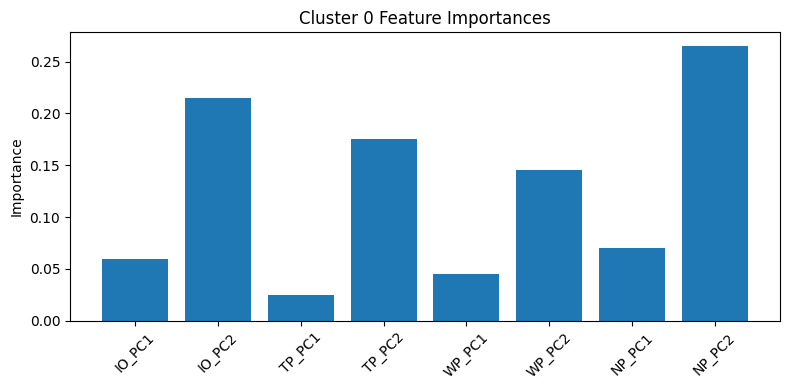

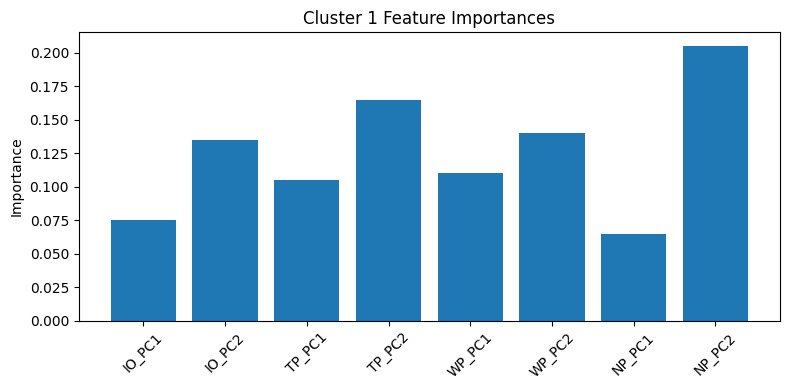

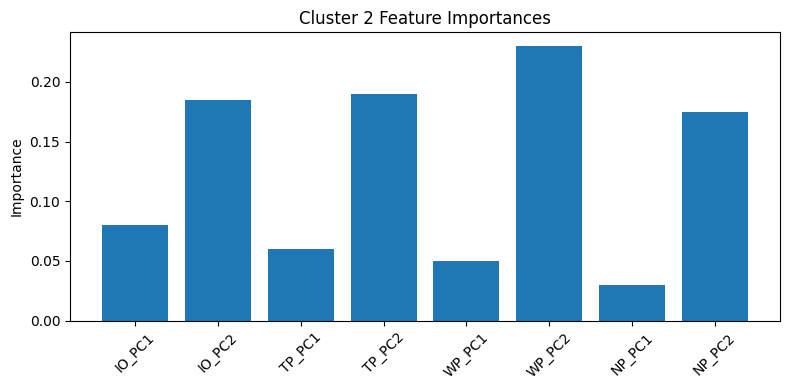

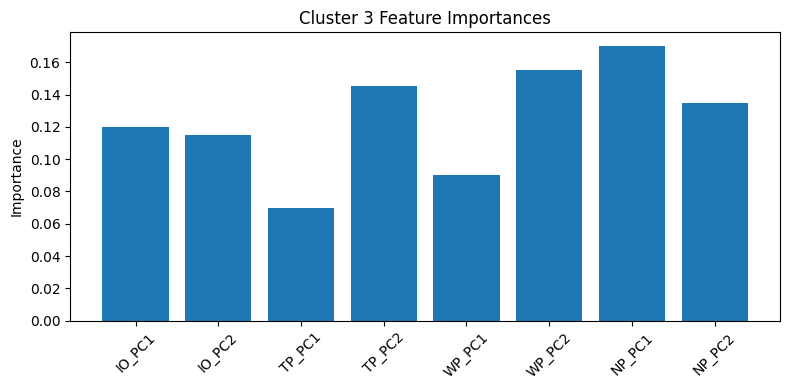

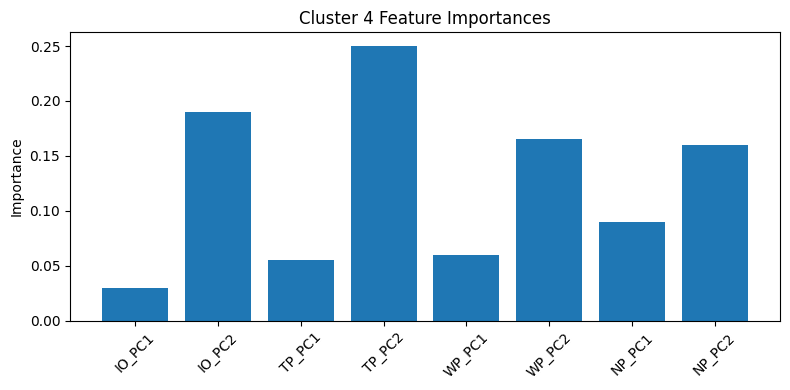

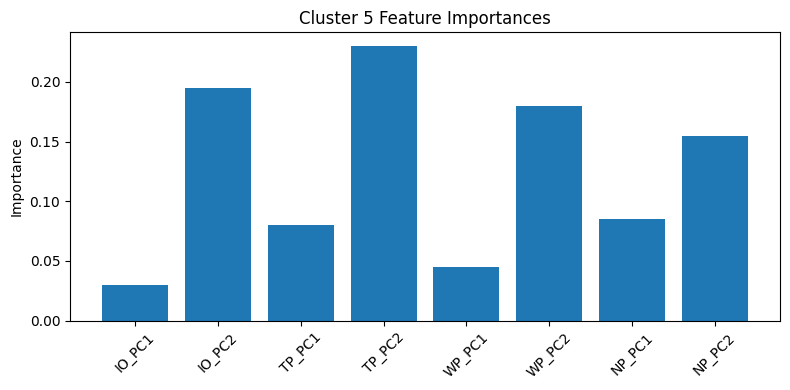

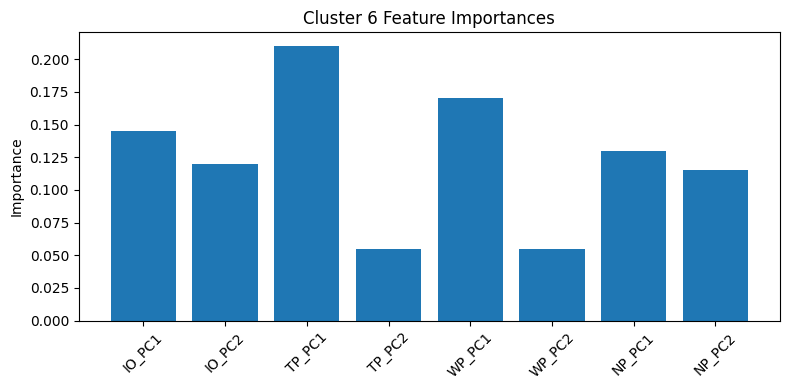

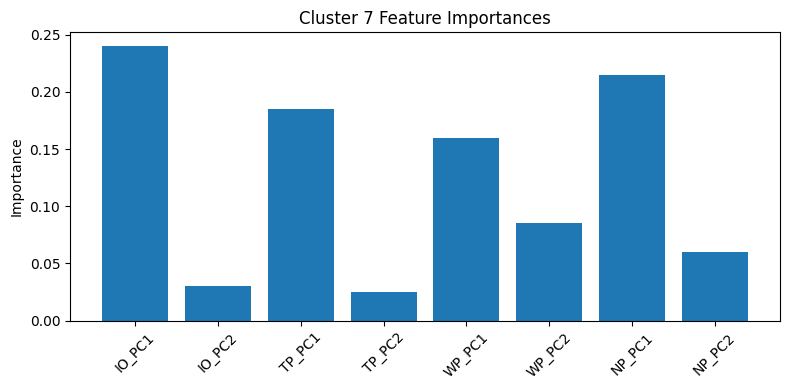

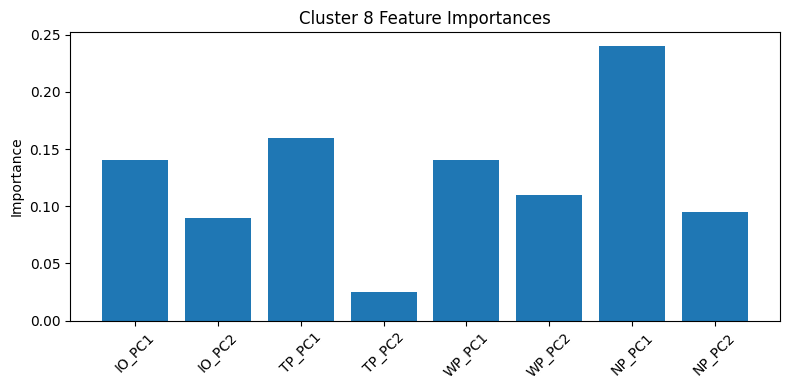

In [97]:
plot_feature_importances(
    rf_models,
    region_names=['IO', 'TP', 'WP', 'NP'],
    pca_components_per_region=2
)


In [98]:
from sklearn.tree import plot_tree

def plot_sample_tree(model, cluster_index, feature_names):
    """
    Visualize the first decision tree in a given RandomForestClassifier.
    """
    if model is None:
        print(f"Cluster {cluster_index} has no model.")
        return
    
    estimator = model.estimators_[0]  # Take the first tree
    plt.figure(figsize=(20, 10))
    plot_tree(estimator, feature_names=feature_names, filled=True, rounded=True, max_depth=3)
    plt.title(f'Decision Tree for Cluster {cluster_index}')
    plt.show()


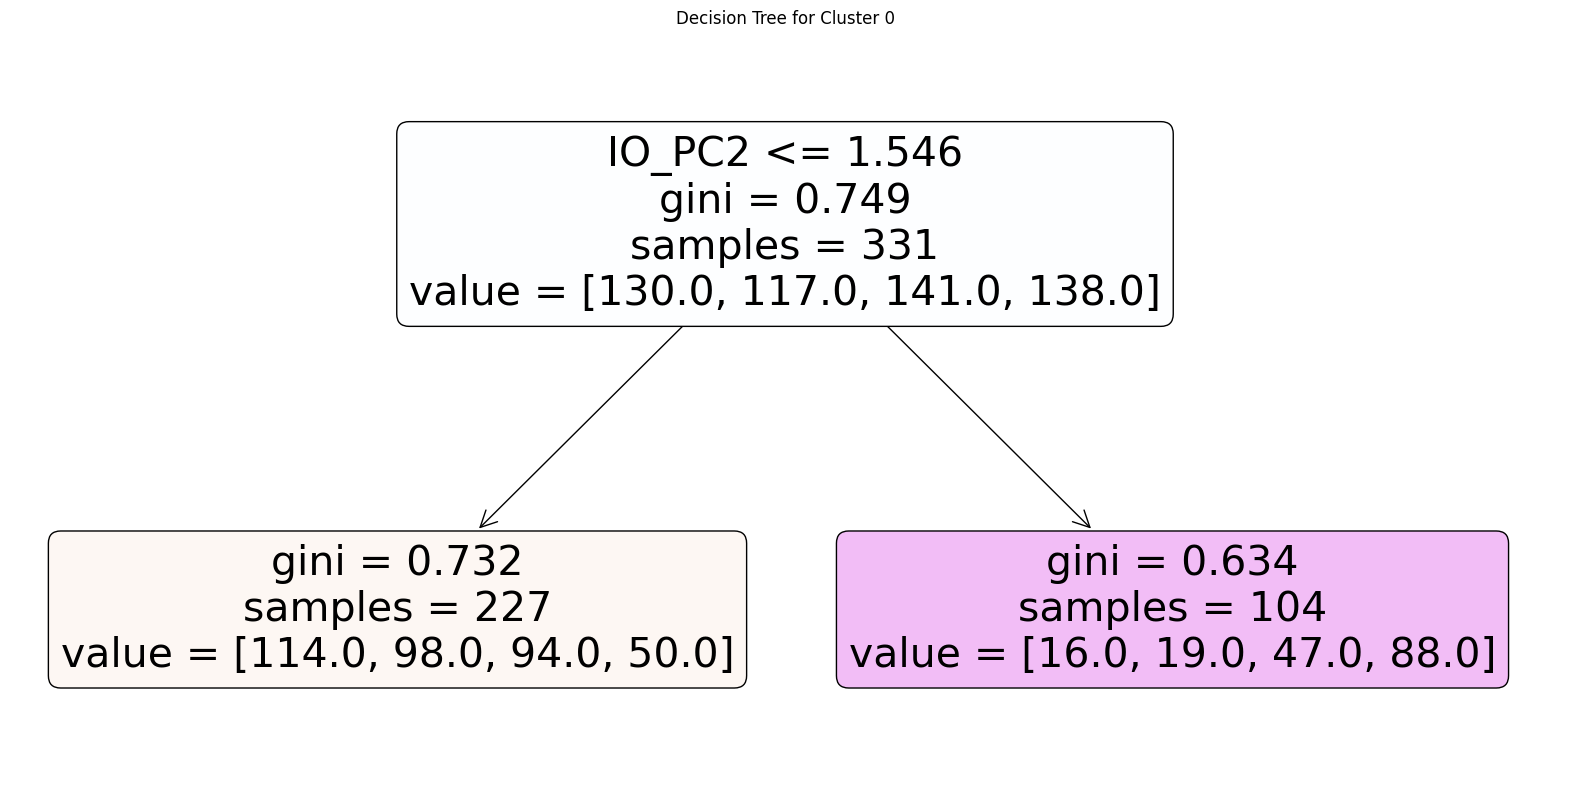

In [99]:
feature_names = [f'{r}_PC{i+1}' for r in ['IO', 'TP', 'WP', 'NP'] for i in range(2)]
plot_sample_tree(rf_models[0], 0, feature_names)  # Visualize cluster 0


In [100]:
def visualize_top_5_important_components_multi_region(pca_list, rf_models, region_shapes, region_names):
    """
    Visualize top 5 most important PCA components across all clusters,
    handling multiple PCA regions concatenated together.

    Args:
        pca_list: list of 4 fitted PCA objects (one per region)
        rf_models: list of 9 Random Forest models (one per cluster)
        region_shapes: list of tuples (F, H, W) for each region
        region_names: list of strings, names of the regions
    """
    total_features = sum(pca.n_components_ for pca in pca_list)
    avg_importances = np.zeros(total_features)

    # Accumulate importances
    for rf_model in rf_models:
        if rf_model is not None:
            avg_importances += rf_model.feature_importances_
    avg_importances /= len([m for m in rf_models if m is not None])

    # Get indices of top 5 components
    top_indices = np.argsort(avg_importances)[-5:][::-1]

    # Figure out region & local PCA index for each feature index
    region_bounds = np.cumsum([0] + [pca.n_components_ for pca in pca_list])
    top_components = []

    for global_idx in top_indices:
        for i in range(len(region_bounds) - 1):
            if region_bounds[i] <= global_idx < region_bounds[i + 1]:
                region_name = region_names[i]
                local_idx = global_idx - region_bounds[i]
                pca_obj = pca_list[i]
                shape = region_shapes[i]
                top_components.append((region_name, local_idx, pca_obj, shape, avg_importances[global_idx]))
                break

    # Plot
    fig, axes = plt.subplots(5, 1, figsize=(10, 15))
    for ax, (region, idx, pca_obj, (F, H, W), importance) in zip(axes, top_components):
        component = pca_obj.components_[idx].reshape(F, H, W)
        component_mean = component.mean(axis=0)
        component_mean = np.flipud(component_mean)

        im = ax.imshow(component_mean, cmap='RdBu_r')
        ax.set_title(f'{region} PC{idx+1} (Avg Importance: {importance:.3f})')
        plt.colorbar(im, ax=ax)

    plt.tight_layout()
    plt.show()

    # Print summary
    print("\nTop 5 Most Important Components Across All Clusters:")
    for region, idx, _, _, importance in top_components:
        print(f"{region} PC{idx+1}: Avg Importance = {importance:.3f}")


In [101]:
def extract_region_data(video_tensor, x_start, x_end, y_start, y_end):
    """
    Extracts raw spatial-temporal region data from padded video tensor.

    Returns:
        region_data: np.ndarray of shape (N_samples, Frames * y * x)
        original_shape: tuple (Frames, y, x)
    """
    # Remove channel dimension (N, 1, F, H, W) -> (N, F, H, W)
    video_np = video_tensor.squeeze(1).numpy()
    
    # Slice spatial region
    region_np = video_np[:, :, y_start:y_end, x_start:x_end]  # (N, F, y, x)

    # Store shape for later reshaping
    _, F, y, x = region_np.shape
    original_shape = (F, y, x)

    # Flatten for PCA (each sample becomes 1D vector)
    region_flat = region_np.reshape(region_np.shape[0], -1)

    # Optional: Remove all-zero columns (from padding)
    non_zero_cols = ~np.all(region_flat == 0, axis=0)
    region_flat = region_flat[:, non_zero_cols]

    return region_flat, original_shape



ValueError: cannot reshape array of size 34440 into shape (24,22,70)

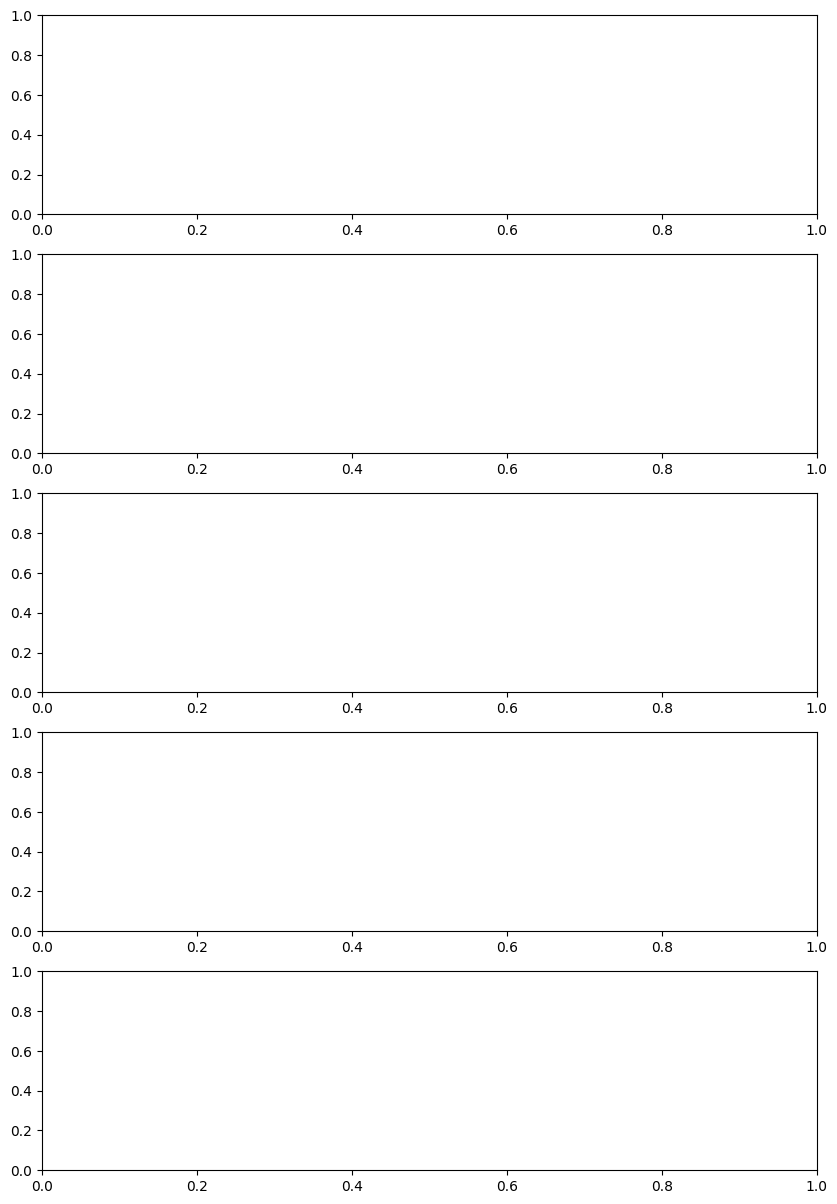

In [102]:
# Region bounds from your original RF code
IO_data, IO_shape = extract_region_data(train_videos, 10, 68, 34, 56)
TP_data, TP_shape = extract_region_data(train_videos, 55, 144, 34, 56)
WP_data, WP_shape = extract_region_data(train_videos, 55, 85, 28, 50)
NP_data, NP_shape = extract_region_data(train_videos, 59, 129, 11, 33)

from sklearn.decomposition import PCA

IO_pca = PCA(n_components=2).fit(IO_data)
TP_pca = PCA(n_components=2).fit(TP_data)
WP_pca = PCA(n_components=2).fit(WP_data)
NP_pca = PCA(n_components=2).fit(NP_data)

visualize_top_5_important_components_multi_region(
    pca_list=[IO_pca, TP_pca, WP_pca, NP_pca],
    rf_models=rf_models,
    region_shapes=[IO_shape, TP_shape, WP_shape, NP_shape],
    region_names=["IO", "TP", "WP", "NP"]
)


In [ ]:
# IO_pca = PCA(n_components=2).fit(io_data)
# TP_pca = PCA(n_components=2).fit(tp_data)
# WP_pca = PCA(n_components=2).fit(wp_data)
# NP_pca = PCA(n_components=2).fit(np_data)

# Shapes of the original data sliced for each region
IO_shape = (24, 22, 58)  # Frames, Height, Width
TP_shape = (24, 22, 89)
WP_shape = (24, 22, 30)
NP_shape = (24, 22, 70)

visualize_top_5_important_components_multi_region(
    pca_list=[IO_pca, TP_pca, WP_pca, NP_pca],
    rf_models=rf_models,
    region_shapes=[IO_shape, TP_shape, WP_shape, NP_shape],
    region_names=["IO", "TP", "WP", "NP"]
)


NameError: name 'io_data' is not defined

In [ ]:
import os
import tqdm
def get_filenames(directory):
    filenames = sorted(os.listdir(directory))
    return [f for f in filenames if f.endswith(".nc")]


def get_path(directory, filename):
    return os.path.join(directory, filename)


def get_basename(path):
    return os.path.basename(path)


def get_month_year(file_name, dtype="ppt"):
    """Get month and year from file name"""
    if dtype == "ppt":
        time = pd.Timestamp("-".join(file_name.split(".")[0].split("_")[1:]))
        month, year = time.month, time.year
    elif dtype == "sst":
        year, month = file_name.split(".")[-2][-6:-2], file_name.split(".")[-2][-2:]
        month, year = int(month), int(year)
    else:
        print(f"dtype {dtype} not implemented. Use ppt or sst.")
        month, year = None, None
    return month, year


def read_xr(path, dtype="ppt"):
    """Read xarray file"""
    file_data = xr.load_dataset(path, engine="netcdf4")
    file_name = get_basename(path)
    month, year = get_month_year(file_name, dtype)
    xr_data = [file_name, year, month]

    if dtype == "ppt":
        file_data = file_data.rename_vars(
            {list(file_data.keys())[1]: "ppt", "longitude": "lon", "latitude": "lat"}
        )

        # Coarsen data to reduce resolution
        file_data = file_data.coarsen(latitude=4, longitude=4, boundary="trim").mean()
        #         file_data = file_data.sel(longitude=slice(-300, -100))

        ##Slice for west coast
        file_data = file_data.sel(longitude=slice(0, 150))

        xr_data.append(file_data.ppt.values)
        columns = list("FYMD")
        columns[-1] = "ppt"

    elif dtype == "sst":
        # Coarsen data to reduce resolution
        #         file_data = file_data.coarsen(lat = 4, lon = 4, boundary = "trim").mean()

        ##Slice for west coast
        #         file_data = file_data.sel(lon=slice(100, 400))

        xr_data.extend([file_data.sst.values, file_data.ssta.values])
        columns = list("FYMDA")
        columns[-2], columns[-1] = "sst", "ssta"

    else:
        print(f"dtype {dtype} not implemented. Use ppt or sst.")

    longitude, latitude = file_data.lon.values, file_data.lat.values
    return xr_data, longitude, latitude, columns


def load_data(directory, dtype="ppt"):
    """Load directory files in a pandas dataframe"""
    filenames = get_filenames(directory)
    data_info_list = []
    for i, file_name in tqdm(enumerate(filenames)):
        path = get_path(directory, file_name)
        xr_data, longitude, latitude, columns = read_xr(path, dtype)
        data_info_list.append(xr_data)
    df = pd.DataFrame([p for p in data_info_list], columns=columns)
    return df, latitude, longitude

In [ ]:
ppt_directory = "data/ppt-nc-1895-2020"

In [ ]:
import os
import tqdm

ppt_df, lat, lon = load_data(ppt_directory, dtype="ppt")

TypeError: 'module' object is not callable

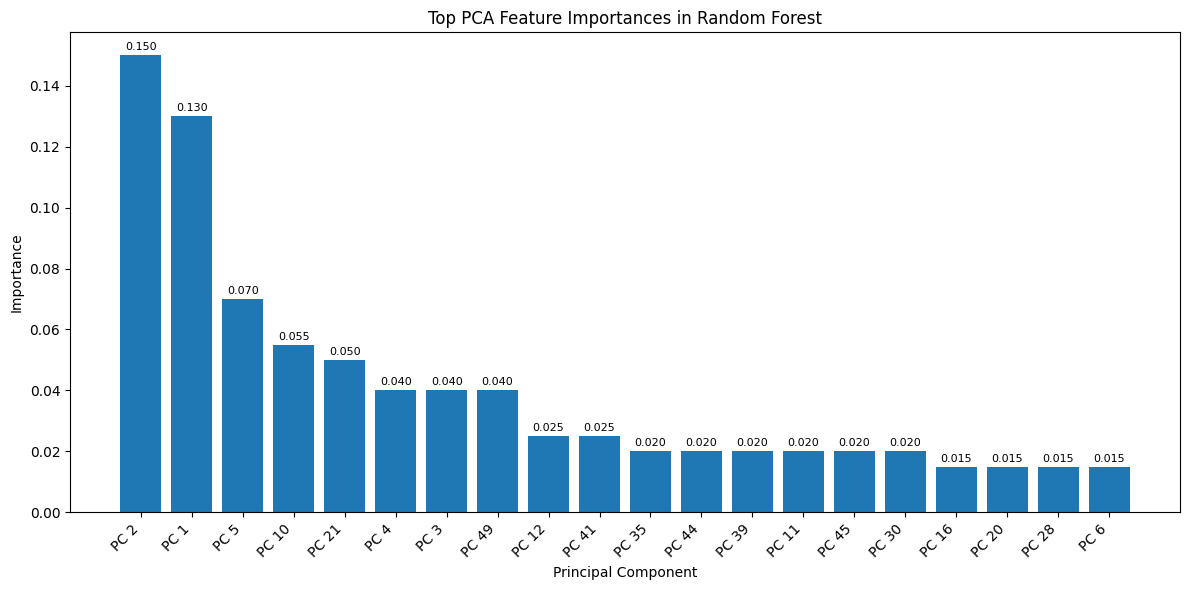

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Use the trained random forest and PCA data
importances = rf.feature_importances_

# Get top N most important features
top_n = 20
indices = np.argsort(importances)[::-1][:top_n]
top_importances = importances[indices]

# Create readable labels like "PC 1", "PC 2", ...
feature_names = [f'PC {i+1}' for i in indices]

# Plot
plt.figure(figsize=(12, 6))
bars = plt.bar(range(top_n), top_importances, tick_label=feature_names)
plt.title("Top PCA Feature Importances in Random Forest")
plt.xlabel("Principal Component")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha='right')

# Add value labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.001, f'{yval:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


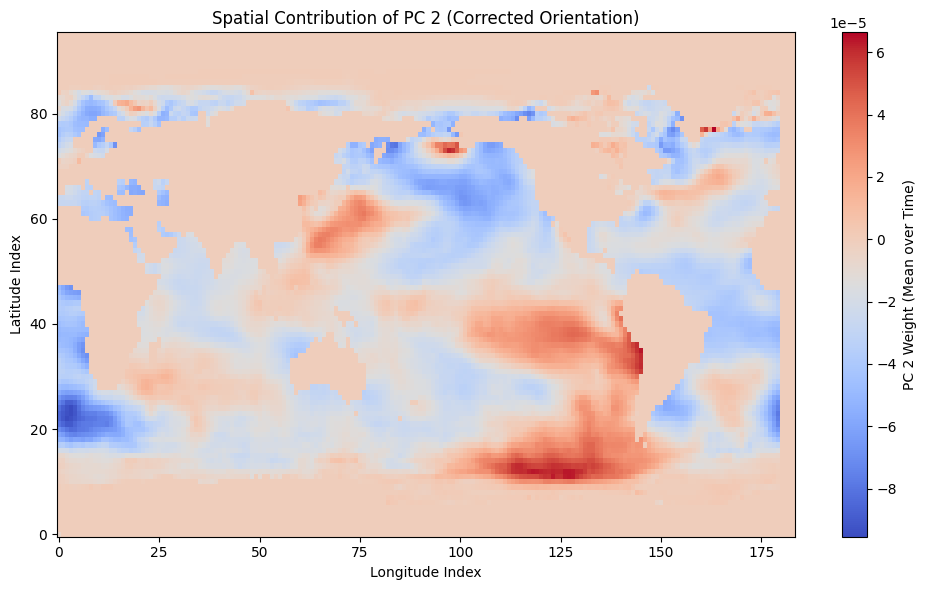

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Assume train_videos.shape = (B, 1, F, H, W)
F, H, W = train_videos.shape[2:]

# Get PC 2 weights from PCA
component = 2
pc2_weights = pca.components_[component-1]  # PC 2

# Reshape and average over time
pc2_image = pc2_weights.reshape(F, H, W)
spatial_contrib = pc2_image.mean(axis=0)  # shape: (H, W)

# Plot with corrected orientation
plt.figure(figsize=(10, 6))
plt.imshow(spatial_contrib, cmap='coolwarm', origin='lower', aspect='auto')
plt.colorbar(label=f'PC {component} Weight (Mean over Time)')
plt.title(f"Spatial Contribution of PC {component} (Corrected Orientation)")
plt.xlabel("Longitude Index")
plt.ylabel("Latitude Index")
plt.tight_layout()
plt.show()


### Fixed positional encoder, applied only to the time dimension

<function run_experiment at 0x14f478940>


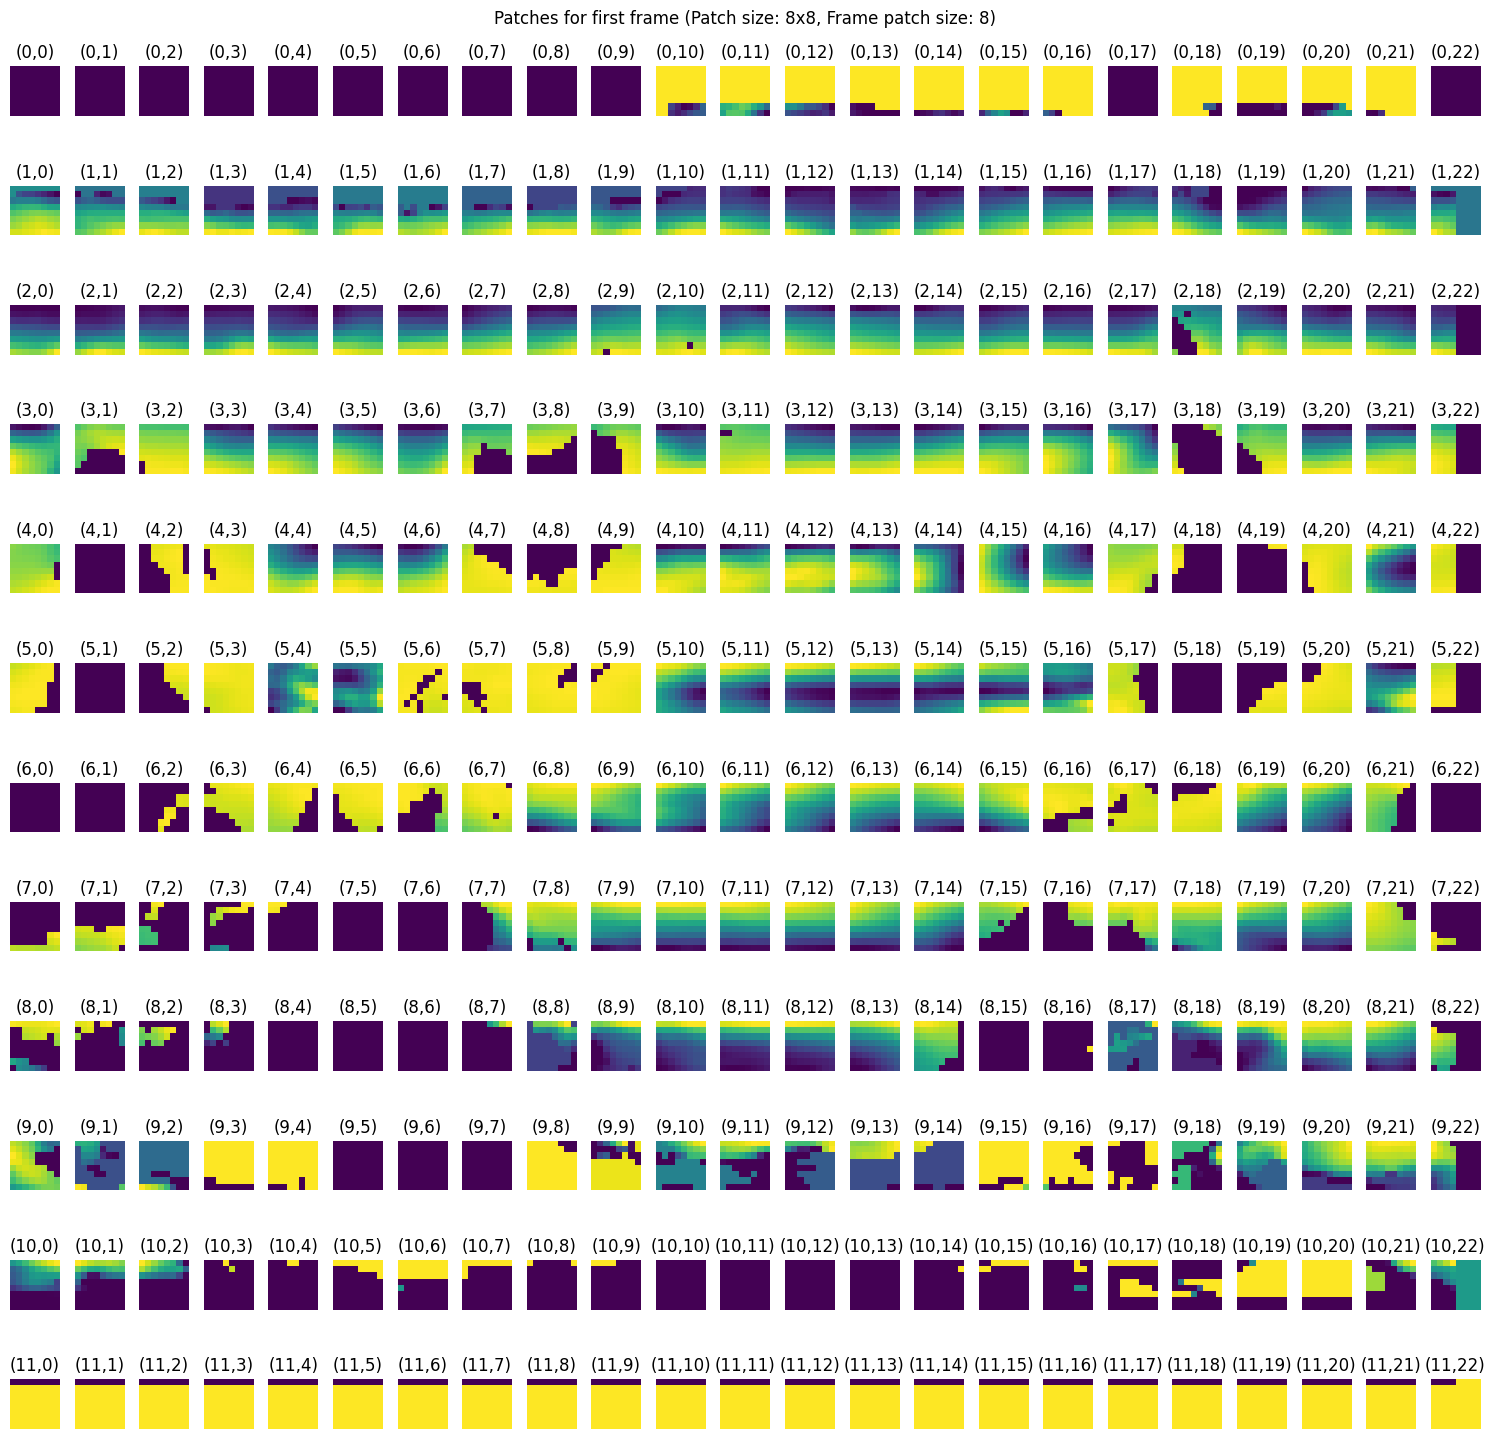


Patch Information:
Total number of patches: 828
Spatial patches per frame: 276
Temporal patches: 3
Patch dimensions: 8x8x8
Using device: cpu
Number of Patches 828 Patch dim 512
Epoch [1/100], Loss: 1.4189, Accuracy: 0.2319
Validation Accuracy: 0.2479, Validation Loss: 1.3987
Epoch [2/100], Loss: 1.3942, Accuracy: 0.2471
Validation Accuracy: 0.2275, Validation Loss: 1.3925
Epoch [3/100], Loss: 1.3928, Accuracy: 0.2353
Validation Accuracy: 0.2441, Validation Loss: 1.3898
Epoch [4/100], Loss: 1.3931, Accuracy: 0.2479
Validation Accuracy: 0.2139, Validation Loss: 1.3952
Epoch [5/100], Loss: 1.3917, Accuracy: 0.2433
Validation Accuracy: 0.2366, Validation Loss: 1.3915
Epoch [6/100], Loss: 1.3907, Accuracy: 0.2395
Validation Accuracy: 0.2351, Validation Loss: 1.3904
Epoch [7/100], Loss: 1.3885, Accuracy: 0.2410
Validation Accuracy: 0.2373, Validation Loss: 1.3889
Epoch [8/100], Loss: 1.3903, Accuracy: 0.2378
Validation Accuracy: 0.2441, Validation Loss: 1.3893
Epoch [9/100], Loss: 1.3885, A

In [ ]:
import vit_3d_9_classes
print(vit_3d_9_classes.run_experiment)  # Check if it's referencing your function
model, history = vit_3d_9_classes.run_experiment(trainloader, testloader)

In [ ]:
model

ViT(
  (transformer): Transformer(
    (layers): ModuleList(
      (0-3): 4 x ModuleList(
        (0): Attention(
          (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (attend): Softmax(dim=-1)
          (dropout): Dropout(p=0.0, inplace=False)
          (to_qkv): Linear(in_features=128, out_features=384, bias=False)
          (to_out): Sequential(
            (0): Linear(in_features=128, out_features=128, bias=True)
            (1): Dropout(p=0.0, inplace=False)
          )
        )
        (1): FeedForward(
          (net): Sequential(
            (0): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
            (1): Linear(in_features=128, out_features=256, bias=True)
            (2): GELU(approximate='none')
            (3): Dropout(p=0.0, inplace=False)
            (4): Linear(in_features=256, out_features=128, bias=True)
            (5): Dropout(p=0.0, inplace=False)
          )
        )
      )
    )
  )
  (to_patch_embedding): Sequential(
    

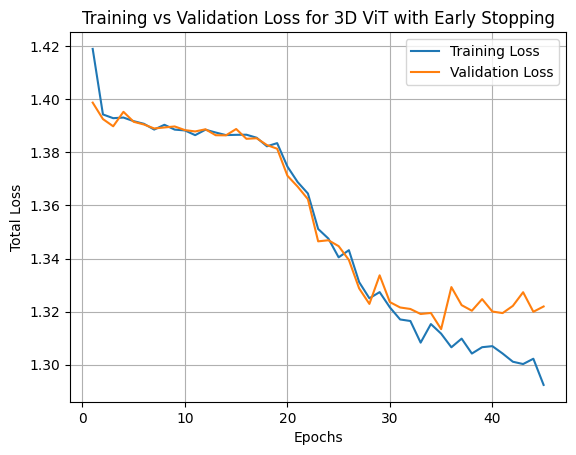

In [ ]:
import matplotlib.pyplot as plt
epochs = range(1, len(history.training_loss) + 1)


plt.plot(epochs, history.training_loss, label="Training Loss")
plt.plot(epochs, history.validation_loss, label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Total Loss")
plt.title("Training vs Validation Loss for 3D ViT with Early Stopping")
plt.legend()
plt.grid(True)
plt.show()


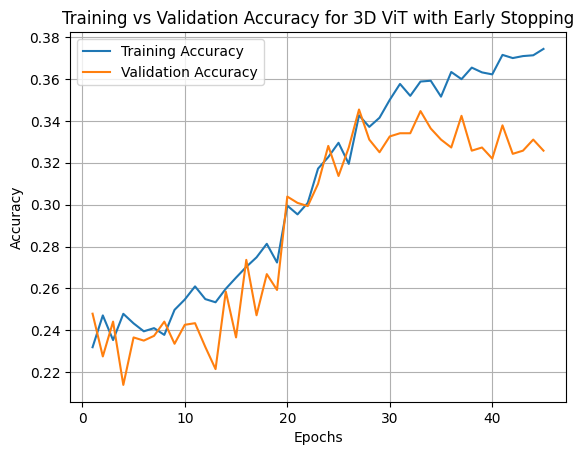

In [ ]:
import matplotlib.pyplot as plt
epochs = range(1, len(history.training_accuracy) + 1)

train_acc = np.array(history.training_accuracy)
valid_acc = np.array(history.validation_accuracy)

plt.plot(epochs, train_acc, label="Training Accuracy")
plt.plot(epochs, valid_acc, label="Validation Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy for 3D ViT with Early Stopping")
plt.legend()
plt.grid(True)
plt.show()

Accuracy for Cluster 1: 34.01%
Accuracy for Cluster 2: 24.49%
Accuracy for Cluster 3: 37.41%
Accuracy for Cluster 4: 29.93%
Accuracy for Cluster 5: 31.29%
Accuracy for Cluster 6: 35.37%
Accuracy for Cluster 7: 24.49%
Accuracy for Cluster 8: 38.78%
Accuracy for Cluster 9: 37.41%


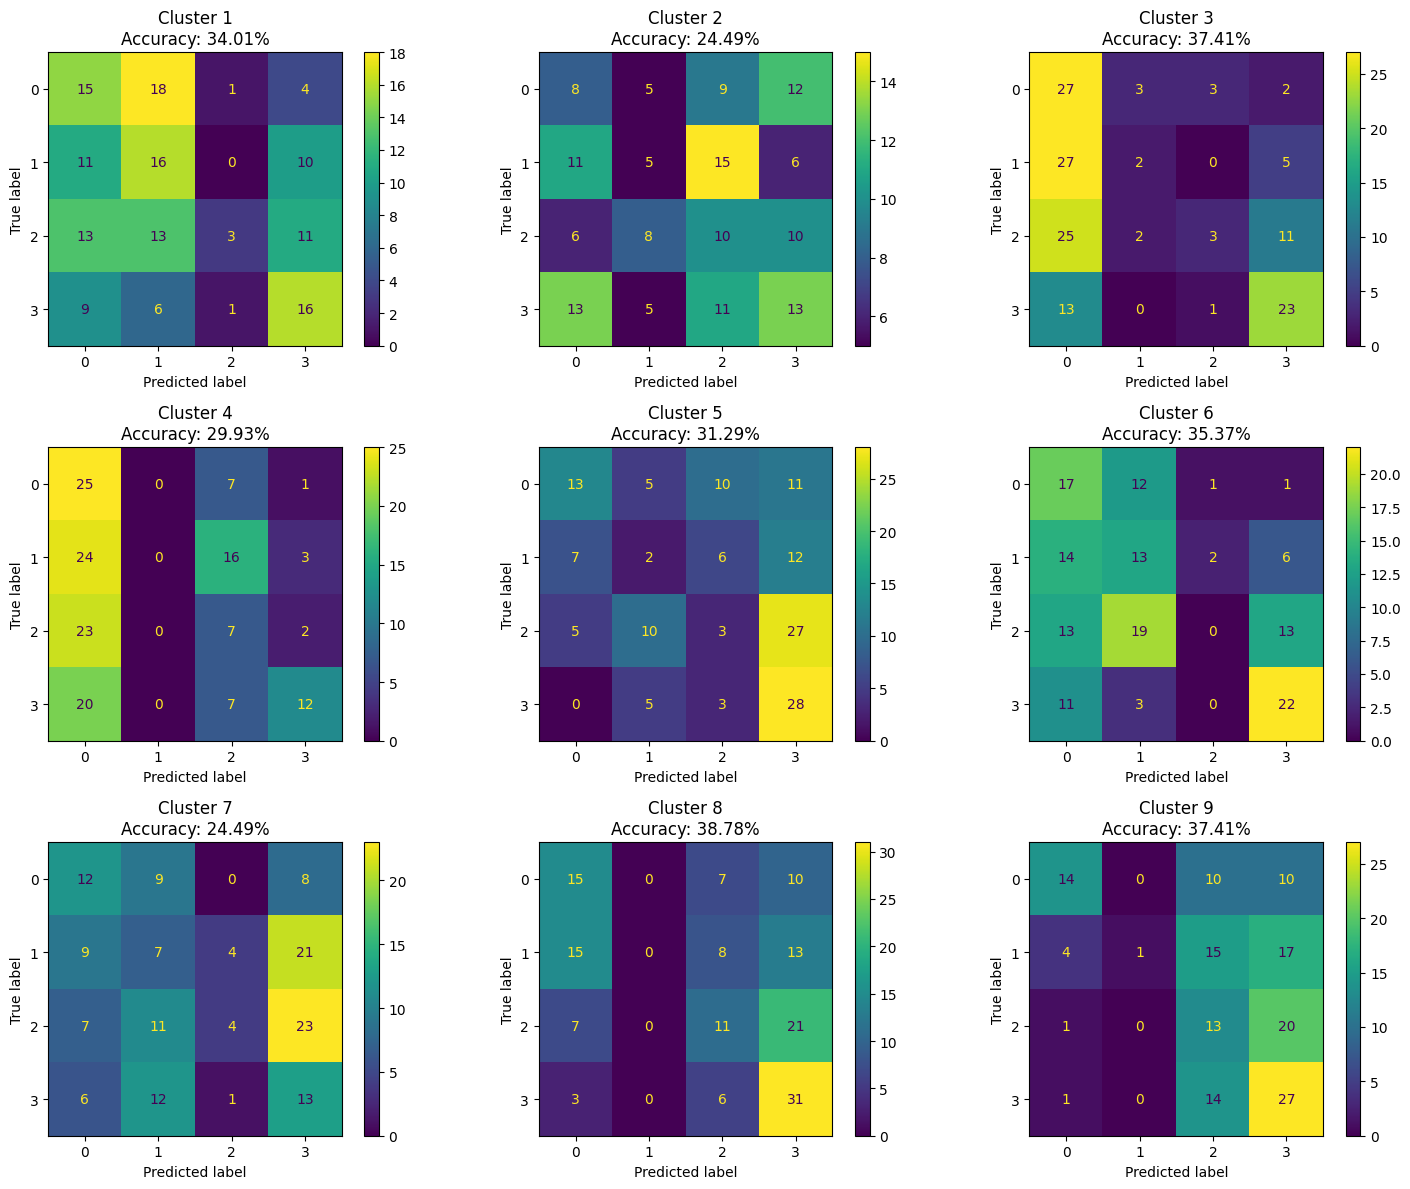

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

y_pred = model(test_videos)
# pred = [np.argmax(x, axis=0) for x in y_pred]
# Ensure y_pred and test_labels are NumPy arrays
y_pred_np = y_pred.detach().cpu().numpy() if isinstance(y_pred, torch.Tensor) else y_pred
test_labels_np = test_labels.detach().cpu().numpy() if isinstance(test_labels, torch.Tensor) else test_labels

# Get predicted class per cluster (argmax over class dimension)
y_pred_classes = np.argmax(y_pred_np, axis=2)  # Shape: (147, 9)

# Plotting one confusion matrix per cluster

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
plt.title("Confusion Matrix for Neural Network")
axes = axes.flatten()

for cluster_idx in range(9):
    y_true_cluster = test_labels_np[:, cluster_idx]
    y_pred_cluster = y_pred_classes[:, cluster_idx]
    
    # Compute accuracy
    acc = accuracy_score(y_true_cluster, y_pred_cluster)
    print(f"Accuracy for Cluster {cluster_idx + 1}: {acc:.2%}")
    
    # Plot confusion matrix
    cm = confusion_matrix(y_true_cluster, y_pred_cluster)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=axes[cluster_idx], values_format='d')
    axes[cluster_idx].set_title(f"Cluster {cluster_idx + 1}\nAccuracy: {acc:.2%}")


plt.tight_layout()
plt.show()


## Attempt at doing this while including start months

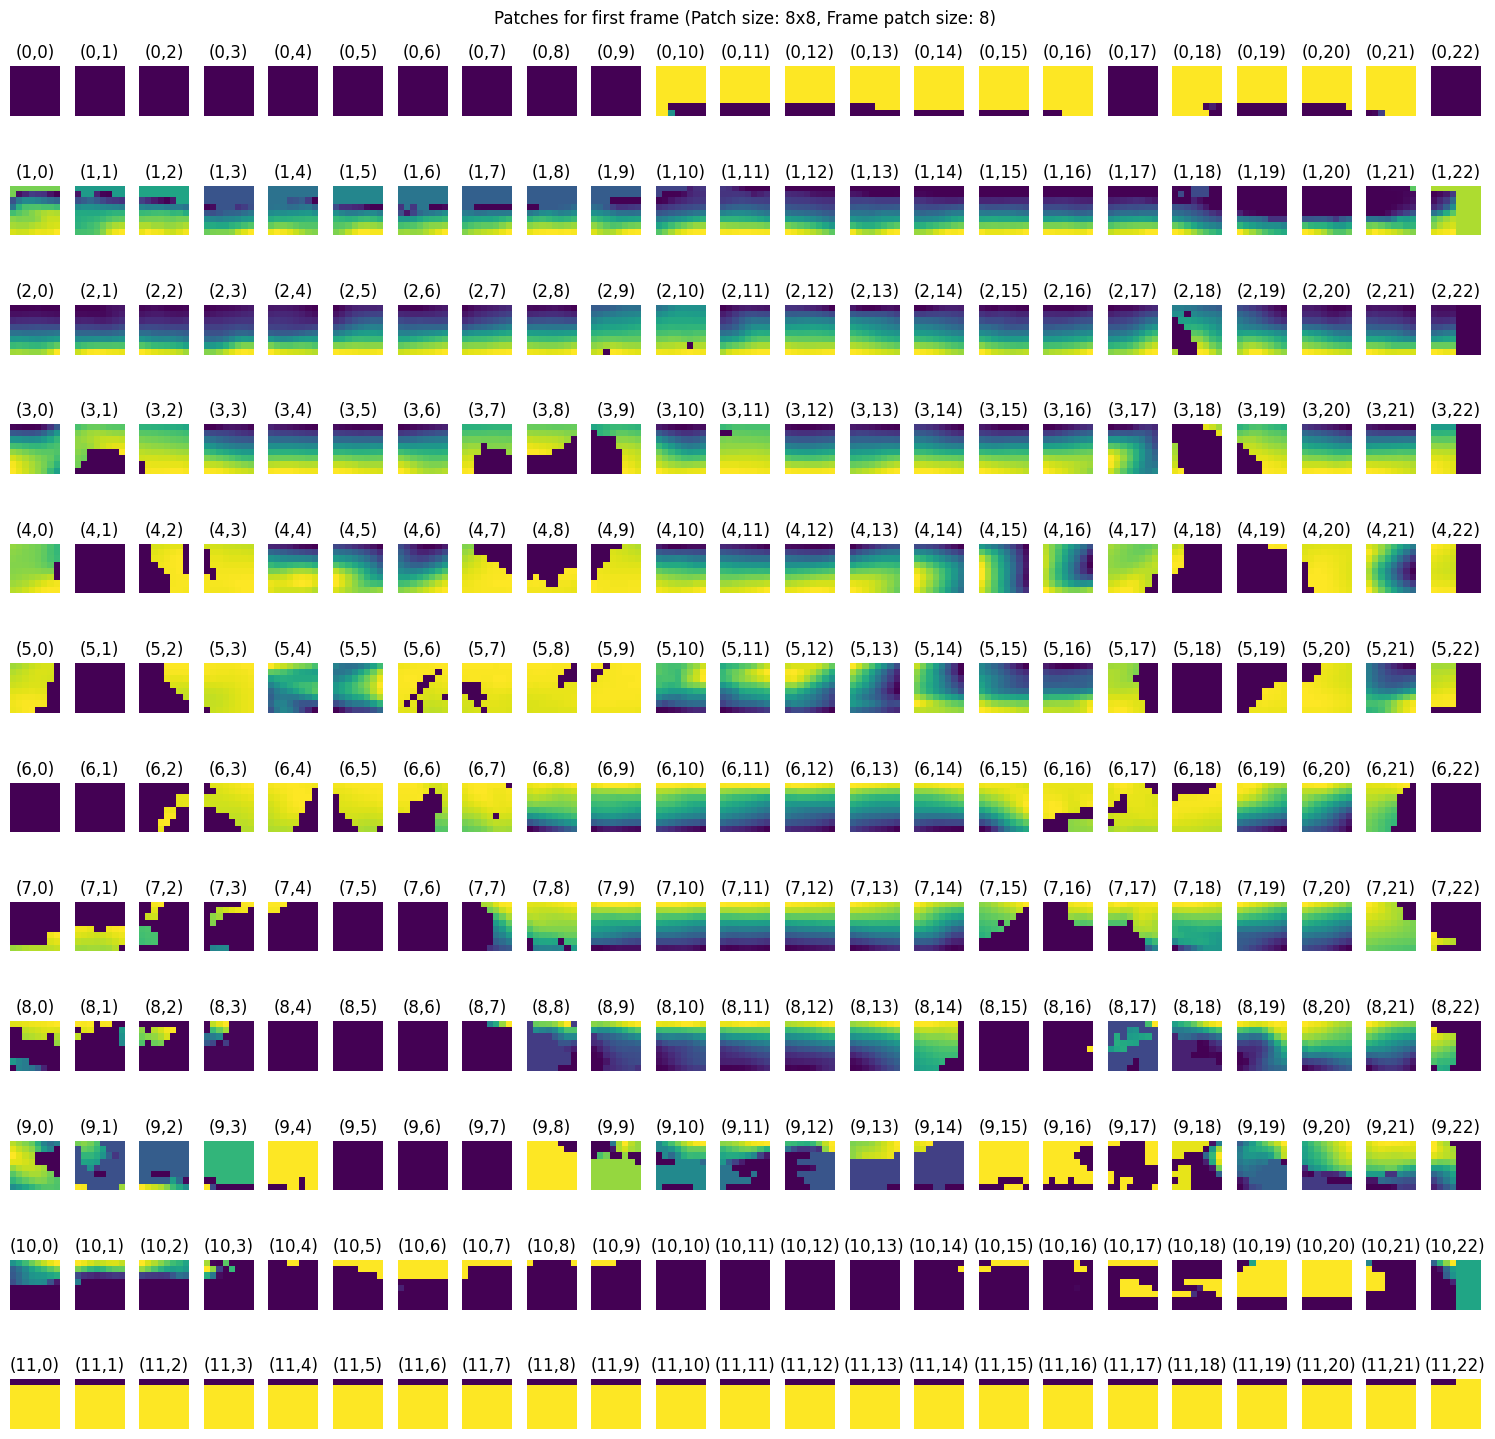


Patch Information:
Total number of patches: 828
Spatial patches per frame: 276
Temporal patches: 3
Patch dimensions: 8x8x8
Using device: cpu
Number of Patches 828 Patch dim 512
Epoch [1/100], Loss: 1.4228, Accuracy: 0.2448
Validation Accuracy: 0.2449, Validation Loss: 1.3919
Epoch [2/100], Loss: 1.3921, Accuracy: 0.2454
Validation Accuracy: 0.2290, Validation Loss: 1.3893
Epoch [3/100], Loss: 1.3917, Accuracy: 0.2443
Validation Accuracy: 0.2320, Validation Loss: 1.3915
Epoch [4/100], Loss: 1.3899, Accuracy: 0.2524
Validation Accuracy: 0.2328, Validation Loss: 1.3902
Epoch [5/100], Loss: 1.3909, Accuracy: 0.2420
Validation Accuracy: 0.2600, Validation Loss: 1.3871
Epoch [6/100], Loss: 1.3890, Accuracy: 0.2473
Validation Accuracy: 0.2268, Validation Loss: 1.3911
Epoch [7/100], Loss: 1.3905, Accuracy: 0.2509
Validation Accuracy: 0.2532, Validation Loss: 1.3876
Epoch [8/100], Loss: 1.3891, Accuracy: 0.2568
Validation Accuracy: 0.2215, Validation Loss: 1.3922
Epoch [9/100], Loss: 1.3894, A

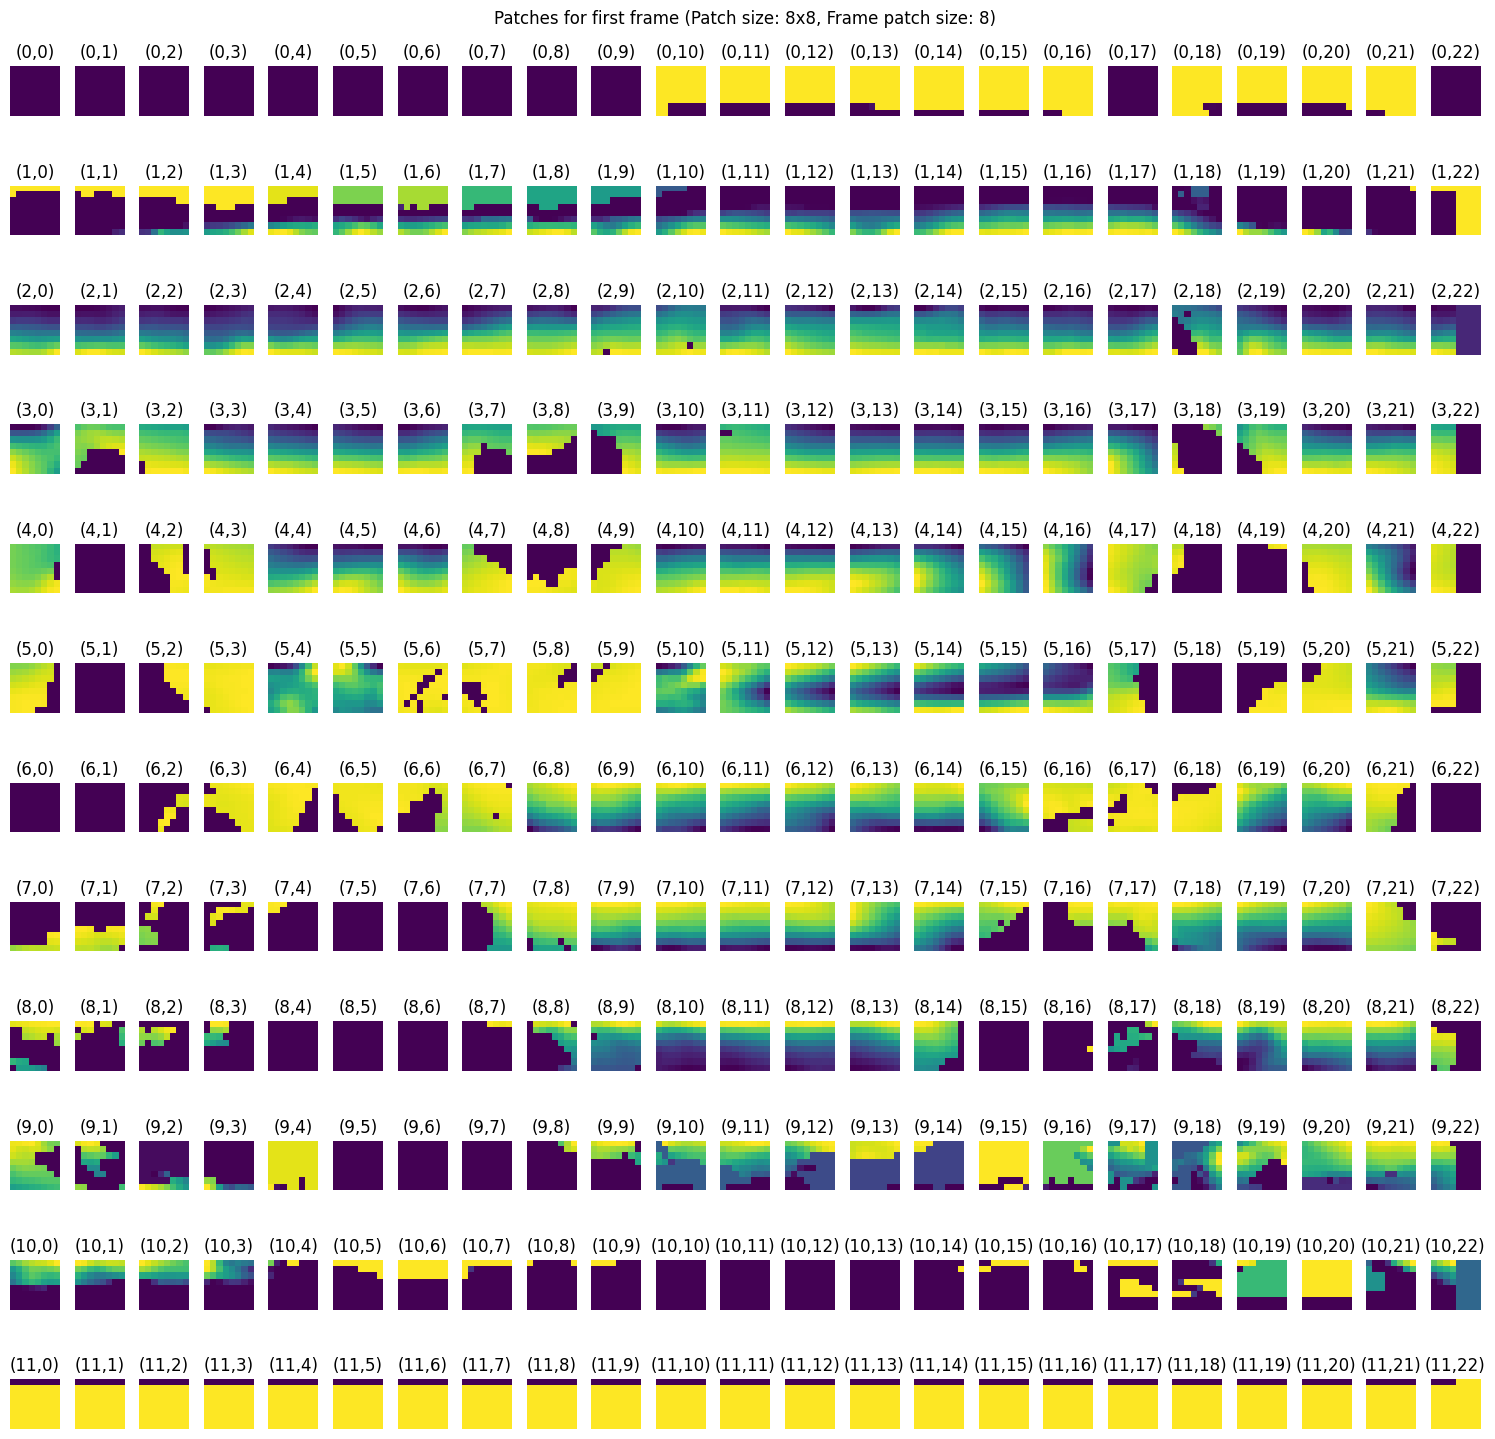


Patch Information:
Total number of patches: 828
Spatial patches per frame: 276
Temporal patches: 3
Patch dimensions: 8x8x8
Using device: cpu
Number of Patches 828 Patch dim 512
Epoch [1/10], Loss: 1.4074, Accuracy: 0.2437
Validation Accuracy: 0.2313, Validation Loss: 1.4025
Epoch [2/10], Loss: 1.3968, Accuracy: 0.2368
Validation Accuracy: 0.2555, Validation Loss: 1.3896


KeyboardInterrupt: 

In [ ]:
import vit_3d_9_classes
# Load the dataset with starting month information
prepared_dataset = vit_3d_9_classes.download_and_prepare_dataset("data/cluster_sst.npz")
(train_videos, train_labels, train_start_month), (test_videos, test_labels, test_start_months) = prepared_dataset

# Create dataloaders with starting month information
trainloader = vit_3d_9_classes.prepare_dataloader(train_videos, train_labels, "train", batch_size=32)
testloader = vit_3d_9_classes.prepare_dataloader(test_videos, test_labels, "test", batch_size=32)

# Run the experiment
model, history = vit_3d_9_classes.run_experiment(trainloader, testloader)

print(vit_3d_9_classes.run_experiment)  # Check if it's referencing your function
model, history = vit_3d_9_classes.run_experiment(trainloader, testloader, epochs=10)



In [ ]:
max(history.validation_accuracy)

0.35600907029478457

In [ ]:
np.save('data/history_temporal_positional_fixed.npy', history)

In [ ]:
min(history.validation_loss)

1.3074666500091552

<function run_experiment at 0x102c19e50>


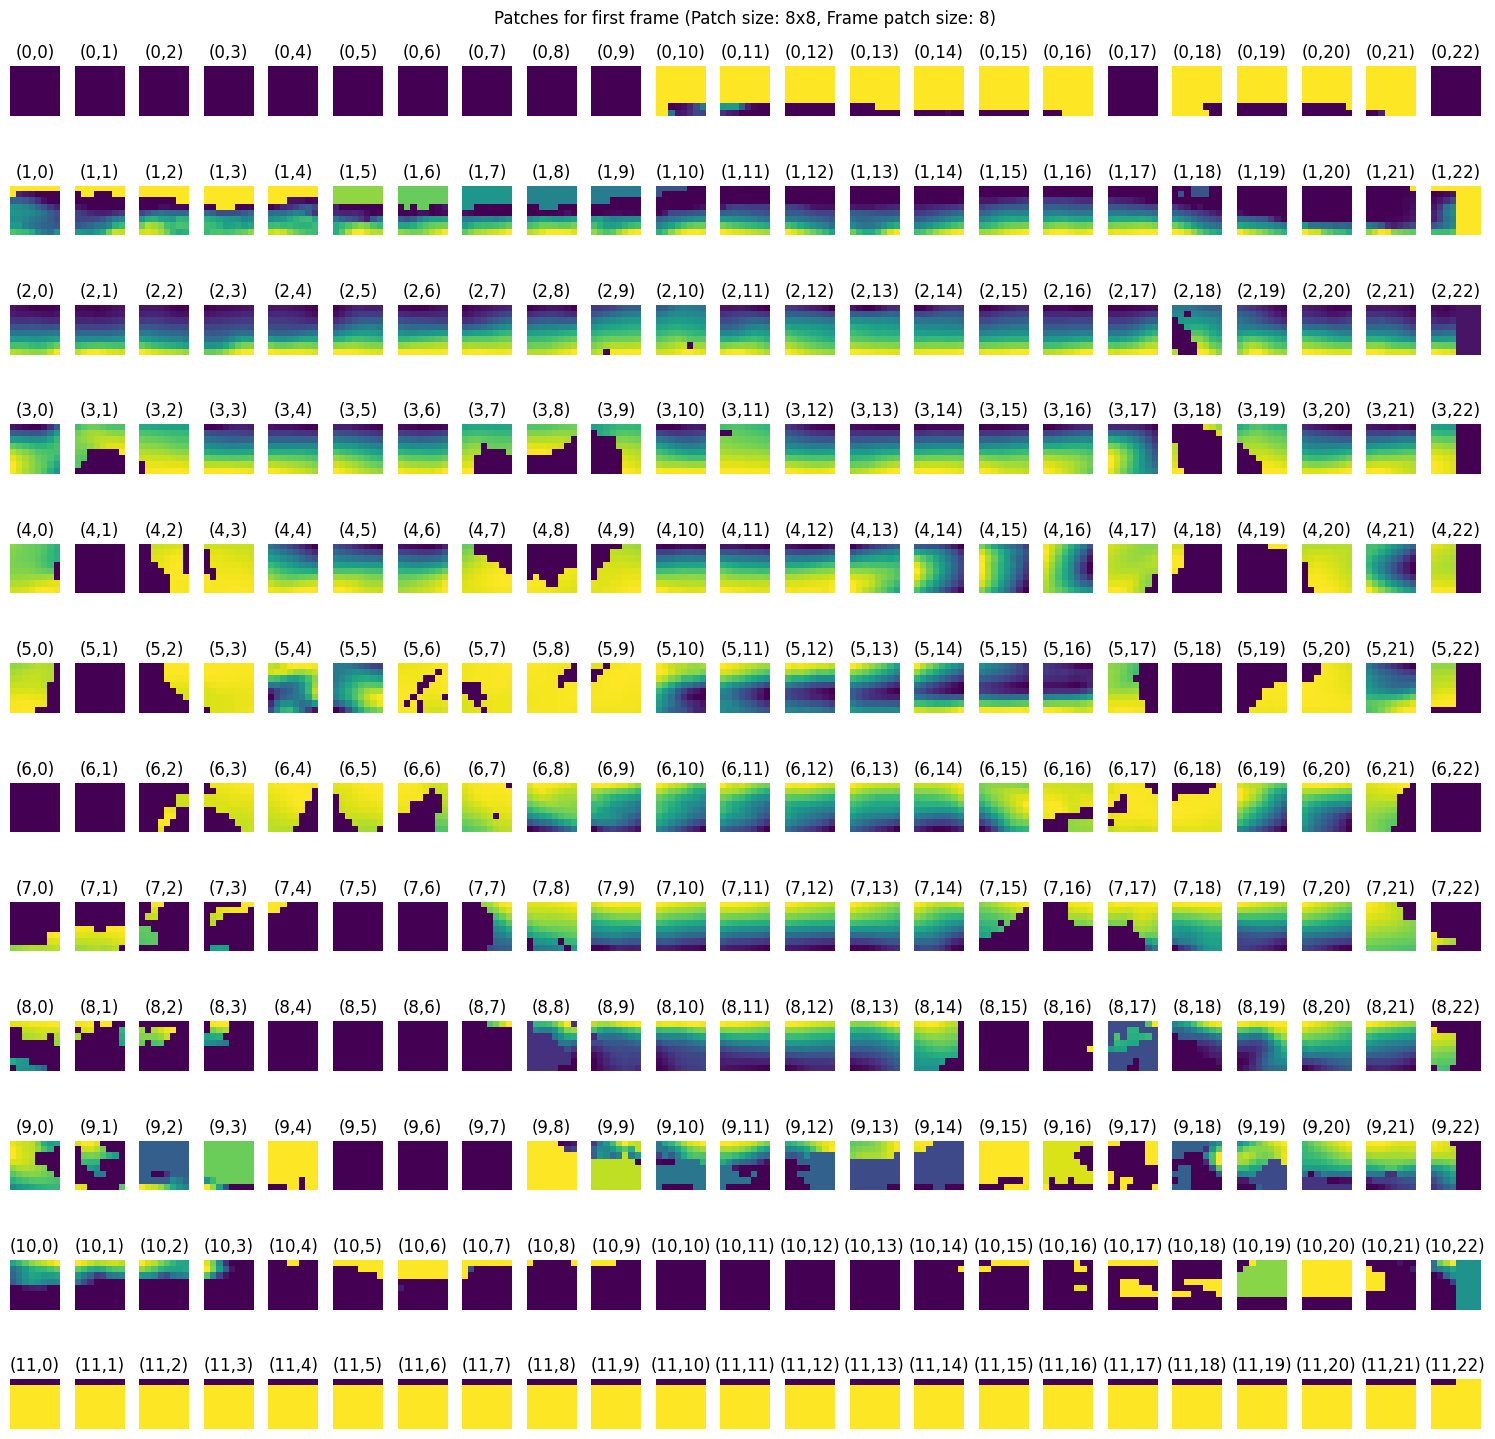


Patch Information:
Total number of patches: 828
Spatial patches per frame: 276
Temporal patches: 3
Patch dimensions: 8x8x8
Using device: cpu
Number of Patches 828 Patch dim 512


ValueError: Expected input batch_size (288) to match target batch_size (32).

In [ ]:
import vit_3d_9_classes
print(vit_3d_9_classes.run_experiment)  # Check if it's referencing your function
model, history = vit_3d_9_classes.run_experiment(trainloader, testloader)

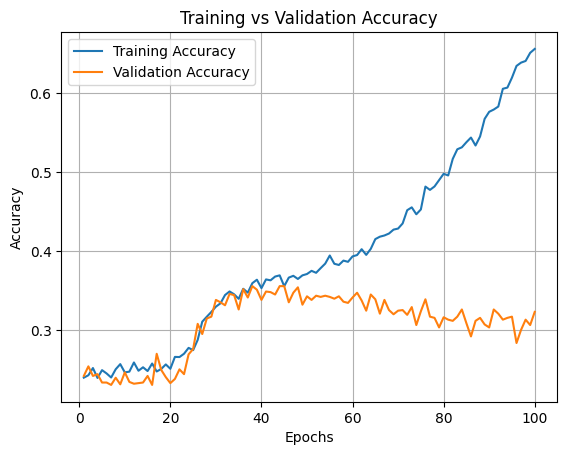

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
epochs = range(1, len(history.training_accuracy) + 1)

train_acc = np.array(history.training_accuracy)
valid_acc = np.array(history.validation_accuracy)

plt.plot(epochs, train_acc, label="Training Accuracy")
plt.plot(epochs, valid_acc, label="Validation Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

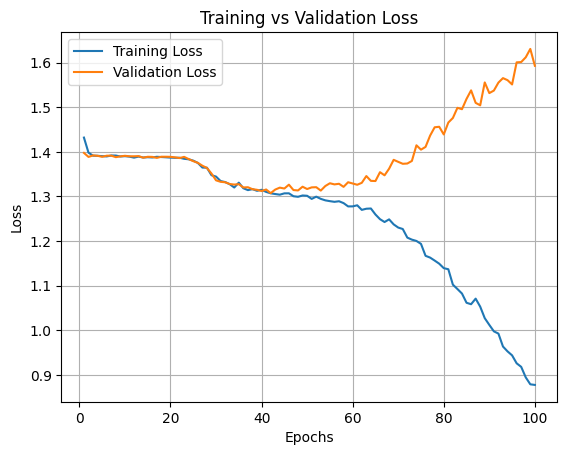

In [ ]:
import matplotlib.pyplot as plt
epochs = range(1, len(history.training_loss) + 1)

# train_loss_norm = np.array(history.training_loss) / max(history.training_loss)
# valid_loss_norm = np.array(history.validation_loss) / max(history.validation_loss)

plt.plot(epochs, history.training_loss, label="Training Loss")
plt.plot(epochs, history.validation_loss, label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import vit_3d_9_classes
print(vit_3d_9_classes.run_experiment)  # Check if it's referencing your function
model, history = vit_3d_9_classes.run_experiment(trainloader, testloader)

<function run_experiment at 0x3c506c550>
Number of Patches 828 Patch dim 512


ValueError: not enough values to unpack (expected 3, got 2)

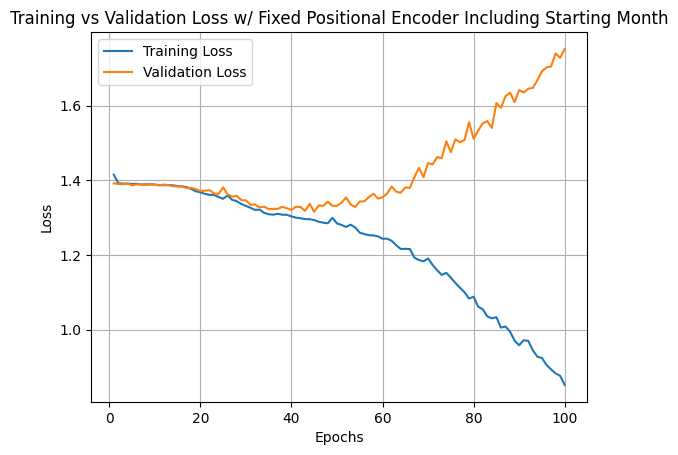

In [ ]:
import matplotlib.pyplot as plt
epochs = range(1, len(history.training_loss) + 1)

plt.plot(epochs, history.training_loss, label="Training Loss")
plt.plot(epochs, history.validation_loss, label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss w/ Fixed Positional Encoder Including Starting Month")
plt.legend()
plt.grid(True)
plt.show()


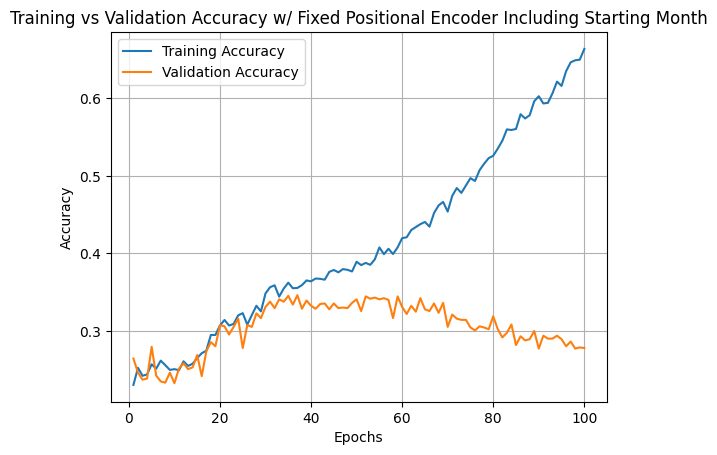

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
epochs = range(1, len(history.training_accuracy) + 1)

train_acc = np.array(history.training_accuracy)
valid_acc = np.array(history.validation_accuracy)

plt.plot(epochs, train_acc, label="Training Accuracy")
plt.plot(epochs, valid_acc, label="Validation Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy w/ Fixed Positional Encoder Including Starting Month")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print(f'Maximum accuracy, {max(history.validation_accuracy)}, Minimum Loss {min(history.validation_loss)}')

In [ ]:
import vivit_pytorch
print(vivit_pytorch.run_experiment)  # Check if it's referencing your function
model, history = vivit_pytorch.run_experiment(trainloader, testloader, validloader)

<function run_experiment at 0x3742179d0>
Number of image patches 276
 Number of frame patches 3
 Patch dim 512
Epoch [1/100], Loss: 26.7554, Accuracy: 0.2634
Validation Accuracy: 0.2698, Validation Loss: 6.917448878288269
Epoch [2/100], Loss: 26.3314, Accuracy: 0.2686
Validation Accuracy: 0.2540, Validation Loss: 6.902013421058655
Epoch [3/100], Loss: 26.3013, Accuracy: 0.2657
Validation Accuracy: 0.2749, Validation Loss: 6.885661840438843
Epoch [4/100], Loss: 26.2997, Accuracy: 0.2682
Validation Accuracy: 0.2548, Validation Loss: 6.8972790241241455
Epoch [5/100], Loss: 26.3140, Accuracy: 0.2710
Validation Accuracy: 0.2556, Validation Loss: 6.937520503997803
Epoch [6/100], Loss: 26.3053, Accuracy: 0.2600
Validation Accuracy: 0.2632, Validation Loss: 6.939423084259033
Epoch [7/100], Loss: 26.3248, Accuracy: 0.2640
Validation Accuracy: 0.2648, Validation Loss: 6.922523856163025
Epoch [8/100], Loss: 26.3036, Accuracy: 0.2600
Validation Accuracy: 0.2665, Validation Loss: 6.913058042526245


run w/ 3d positional embedding

In [ ]:
import vit_3d_9_classes
# Load the dataset with starting month information
prepared_dataset = vit_3d_9_classes.download_and_prepare_dataset("data/cluster_sst.npz")
(train_videos, train_labels, train_start_months), (test_videos, test_labels, test_start_months) = prepared_dataset

# Create dataloaders with starting month information
trainloader = vit_3d_9_classes.prepare_dataloader(train_videos, train_labels, "train", batch_size=32)
testloader = vit_3d_9_classes.prepare_dataloader(test_videos, test_labels, "test", batch_size=32)

# Run the experiment
# model, history = vit_3d_9_classes.run_experiment(trainloader, testloader)

print(vit_3d_9_classes.run_experiment)  # Check if it's referencing your function
model, history = vit_3d_9_classes.run_experiment(trainloader, testloader, epochs=100)



<function run_experiment at 0x3064b09d0>
Number of Patches 828 Patch dim 512
Epoch [1/100], Loss: 1.4156, Accuracy: 0.2306
Validation Accuracy: 0.2646, Validation Loss: 1.3921
Epoch [2/100], Loss: 1.3925, Accuracy: 0.2526
Validation Accuracy: 0.2464, Validation Loss: 1.3908
Epoch [3/100], Loss: 1.3915, Accuracy: 0.2424
Validation Accuracy: 0.2373, Validation Loss: 1.3897
Epoch [4/100], Loss: 1.3914, Accuracy: 0.2441
Validation Accuracy: 0.2389, Validation Loss: 1.3914
Epoch [5/100], Loss: 1.3905, Accuracy: 0.2572
Validation Accuracy: 0.2797, Validation Loss: 1.3870
Epoch [6/100], Loss: 1.3909, Accuracy: 0.2515
Validation Accuracy: 0.2426, Validation Loss: 1.3894
Epoch [7/100], Loss: 1.3892, Accuracy: 0.2619
Validation Accuracy: 0.2351, Validation Loss: 1.3888
Epoch [8/100], Loss: 1.3886, Accuracy: 0.2560
Validation Accuracy: 0.2336, Validation Loss: 1.3911
Epoch [9/100], Loss: 1.3897, Accuracy: 0.2500
Validation Accuracy: 0.2464, Validation Loss: 1.3884
Epoch [10/100], Loss: 1.3890, Ac

In [ ]:
import torch

def print_top_classes(output, sample_labels):
    # Apply softmax to get probabilities
    probabilities = torch.softmax(output, dim=2)  # Assuming output shape is [1, 9, num_classes]
    
    predictions = output[0]          # shape: [9, num_classes]
    probs = probabilities[0]         # shape: [9, num_classes]

    for cluster in range(9):
        print(f'Cluster {cluster+1}:')

        # Get list of (class_index, probability) pairs
        class_probs = list(enumerate(probs[cluster].tolist()))
        # Sort by probability descending
        class_probs_sorted = sorted(class_probs, key=lambda x: x[1], reverse=True)

        for cls_idx, prob in class_probs_sorted:
            value = predictions[cluster, cls_idx].item()
            print(f'\t{cls_idx}: value = {value:.3f}, prob = {prob * 100:.1f}%')

        # Optionally print the most probable class separately
        top_class_idx, top_prob = class_probs_sorted[0]
        print(f'-> Class:\t{top_class_idx} (with prob = {top_prob * 100:.1f}%)\n-> Actual:\t{sample_labels[cluster]}')


In [ ]:
import torch
from PIL import Image, ImageDraw, ImageFont
import io
from IPython.display import display, Image as IPyImage

def display_tensor_as_gif(tensor, duration=200, scale=2):
    """
    Displays a [1, T, H, W] tensor as a grayscale animated GIF in a Jupyter cell.
    - Flips each frame vertically for correct orientation.
    - Enlarges each frame by the given scale factor.
    - Adds frame number labels in the bottom-left corner.
    """
    tensor = tensor.squeeze(0)  # Shape: [T, H, W]
    frames = []

    # Normalize to [0, 255]
    tensor = tensor - tensor.min()
    tensor = tensor / tensor.max()
    tensor = (tensor * 255).byte()

    for i, frame_tensor in enumerate(tensor):
        # Convert to PIL Image and flip
        img = Image.fromarray(frame_tensor.numpy(), mode='L')
        img = img.transpose(Image.FLIP_TOP_BOTTOM)

        # Resize (scale up)
        img = img.resize((img.width * scale, img.height * scale), Image.NEAREST)

        # Draw label
        draw = ImageDraw.Draw(img)
        label = f"Frame {i}"
        draw.text((10, img.height - 20), label, fill=255)  # Bottom-left corner

        frames.append(img)

    # Save GIF to an in-memory buffer
    buf = io.BytesIO()
    frames[0].save(buf, format='GIF', append_images=frames[1:], save_all=True, duration=duration, loop=0)
    buf.seek(0)

    return IPyImage(data=buf.read(), format='gif')


Start month is 10


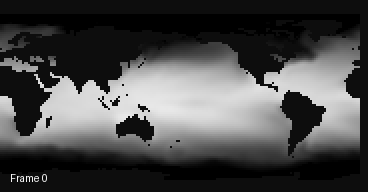

Cluster 1:
	3: value = 2.769, prob = 91.4%
	2: value = -0.284, prob = 4.3%
	1: value = -0.459, prob = 3.6%
	0: value = -2.195, prob = 0.6%
-> Class:	3 (with prob = 91.4%)
-> Actual:	3
Cluster 2:
	2: value = 0.402, prob = 35.8%
	0: value = 0.065, prob = 25.5%
	1: value = 0.012, prob = 24.2%
	3: value = -0.503, prob = 14.5%
-> Class:	2 (with prob = 35.8%)
-> Actual:	1
Cluster 3:
	3: value = 2.264, prob = 85.0%
	2: value = 0.103, prob = 9.8%
	1: value = -0.803, prob = 4.0%
	0: value = -1.925, prob = 1.3%
-> Class:	3 (with prob = 85.0%)
-> Actual:	3
Cluster 4:
	3: value = 1.944, prob = 63.7%
	2: value = 0.838, prob = 21.1%
	1: value = 0.215, prob = 11.3%
	0: value = -0.845, prob = 3.9%
-> Class:	3 (with prob = 63.7%)
-> Actual:	3
Cluster 5:
	3: value = 0.938, prob = 43.7%
	0: value = 0.512, prob = 28.5%
	1: value = 0.072, prob = 18.4%
	2: value = -0.600, prob = 9.4%
-> Class:	3 (with prob = 43.7%)
-> Actual:	0
Cluster 6:
	3: value = 1.127, prob = 60.0%
	2: value = 0.187, prob = 23.4%
	0: v

In [ ]:
import torch
# import utils
sample = test_videos[-1]
sample_labels = test_labels[-1]
sample_start_month = test_start_months[-1]

output = model(sample.unsqueeze(0))

print(f"Start month is {sample_start_month}")
sample.shape
display(display_tensor_as_gif(sample))
print_top_classes(output, sample_labels)


In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

y_pred = model(test_videos)
# pred = [np.argmax(x, axis=0) for x in y_pred]
# Ensure y_pred and test_labels are NumPy arrays
y_pred_np = y_pred.detach().cpu().numpy() if isinstance(y_pred, torch.Tensor) else y_pred
test_labels_np = test_labels.detach().cpu().numpy() if isinstance(test_labels, torch.Tensor) else test_labels

# Get predicted class per cluster (argmax over class dimension)
y_pred_classes = np.argmax(y_pred_np, axis=2)  # Shape: (147, 9)

# Plotting one confusion matrix per cluster

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
plt.title("Confusion Matrix for Neural Network")
axes = axes.flatten()

for cluster_idx in range(9):
    y_true_cluster = test_labels_np[:, cluster_idx]
    y_pred_cluster = y_pred_classes[:, cluster_idx]
    
    # Compute accuracy
    acc = accuracy_score(y_true_cluster, y_pred_cluster)
    print(f"Accuracy for Cluster {cluster_idx + 1}: {acc:.2%}")
    
    # Plot confusion matrix
    cm = confusion_matrix(y_true_cluster, y_pred_cluster)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=axes[cluster_idx], values_format='d')
    axes[cluster_idx].set_title(f"Cluster {cluster_idx + 1}\nAccuracy: {acc:.2%}")


plt.tight_layout()
plt.show()


NameError: name 'model' is not defined

In [ ]:
model

ViT(
  (transformer): Transformer(
    (layers): ModuleList(
      (0-3): 4 x ModuleList(
        (0): Attention(
          (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (attend): Softmax(dim=-1)
          (dropout): Dropout(p=0.0, inplace=False)
          (to_qkv): Linear(in_features=128, out_features=384, bias=False)
          (to_out): Sequential(
            (0): Linear(in_features=128, out_features=128, bias=True)
            (1): Dropout(p=0.0, inplace=False)
          )
        )
        (1): FeedForward(
          (net): Sequential(
            (0): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
            (1): Linear(in_features=128, out_features=256, bias=True)
            (2): GELU(approximate='none')
            (3): Dropout(p=0.0, inplace=False)
            (4): Linear(in_features=256, out_features=128, bias=True)
            (5): Dropout(p=0.0, inplace=False)
          )
        )
      )
    )
  )
  (to_patch_embedding): Sequential(
    

In [ ]:
model = LogisticRegression()

test_preds = []
test_labels = []

for i in range(9):
# Get data for this cluster
    X_train, X_test, y_train, y_test = get_cluster_data(i)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    test_preds.append(preds.tolist())
    test_labels.append(y_test.tolist())
